<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/11_model_baselines_FULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB11_FULL — Baselines temporais, modelos supervisionados e lead time por célula

Pipeline PPCOMP/DM — ramo `_FULL` · Borg 2019 completo por célula · etapa de modelagem supervisionada tabular.

## 1. Objetivo científico

Este notebook avalia, no ramo `_FULL`, se os cenários promovidos pelo **NB10_FULL** oferecem suporte empírico suficiente para modelagem supervisionada de antecipação de falhas por célula Borg.

A etapa compara baselines temporais causais e modelos tabulares supervisionados sob validação temporal, preservando a unidade experimental `cell_id` e a rastreabilidade do corte treino/teste herdado. Cada célula `a`–`h` é tratada como uma réplica independente do experimento, evitando a concatenação artificial de séries com distribuições operacionais distintas.

O **NB11_FULL** é a etapa central de modelagem supervisionada tabular do ramo `_FULL`. Ele aplica, no Borg 2019 completo por célula, a formulação desenvolvida no protótipo Kaggle ajustado, avaliando modelabilidade, heterogeneidade e desempenho preditivo com critérios explícitos por cenário.

Em termos práticos, esta etapa busca responder a quatro perguntas principais:

1. quais células e cenários possuem suporte supervisionado suficiente para modelagem;
2. se baselines temporais simples já explicam parte relevante do sinal de antecipação;
3. se modelos tabulares supervisionados agregam desempenho em relação a esses baselines;
4. quais escores e artefatos podem ser encaminhados, com rastreabilidade, para as etapas posteriores do ramo `_FULL`.

## 2. Posição no pipeline `_FULL`

O NB11_FULL consome os artefatos do **NB10_FULL**, que consolida cenários derivados das etapas de episódios, atributos, estados e diagnóstico de limiares. A cadeia esperada é:

```text
NB99_A/B/C  →  Parquet FULL model-facing
NB04_FULL   →  episódios, limiares e gate episódico preliminar
NB05_FULL   →  engenharia de atributos causais
NB06_FULL   →  estados e alvo supervisionado de antecipação
NB10_FULL   →  diagnósticos de limiar e cenários promovidos
NB11_FULL   →  baselines, modelos, calibração, lead time e consolidação por célula
```

A entrada imediata do NB11_FULL é o conjunto de `states` promovido pelo NB10_FULL. Antes da modelagem, o notebook valida se os conjuntos de atributos esperados foram preservados, se o alvo supervisionado é recuperável e se há suporte mínimo para treino e teste.

A saída do NB11_FULL tem papel estratégico no pipeline: ela define a primeira evidência supervisionada tabular em escala `_FULL`, produzindo métricas, escores, diagnósticos de calibração, lead time e registros de modelabilidade por célula. Esses artefatos alimentam as etapas posteriores de sensibilidade, modelos sequenciais, análise de decisão e visualização final.

## 3. Hipóteses e decisões metodológicas

1. **Unidade experimental por célula.** Cada `cell_id` é processado separadamente. As células não são concatenadas como uma série temporal única; a pasta `aggregate/` apenas consolida resultados já avaliados por célula.

2. **Split temporal herdado.** O corte treino/teste fixo usa `train_cutoff_idx` e `train_cutoff_bucket_id` herdados do upstream. O NB11_FULL não rederiva o split por `floor(n × 0,80)`, preservando a continuidade metodológica do pipeline.

3. **Alvo supervisionado de antecipação.** A tarefa é estimar a entrada futura em estado crítico dentro do horizonte `H`, usando `y_anticipation`/`y_nb11`. Linhas sem horizonte supervisionado completo são removidas por `eligible_supervised` ou flags equivalentes.

4. **Features causais e congeladas.** Os conjuntos `raw_7` e `temporal_core` são whitelists causais. O notebook valida se o conjunto efetivo recebido mantém `raw_7 = 7/7` e `temporal_core = 14/14`, evitando perda silenciosa de atributos.

5. **Gate de modelabilidade.** O gate do NB04_FULL é preservado como evidência upstream. Quando seu status é pendente ou consultivo, a modelabilidade efetiva no NB11_FULL é decidida com base no suporte supervisionado observado no treino e no teste.

6. **Dois escopos de agregação.** O agregado `all_cells_including_descriptive` descreve a população FULL completa. O agregado `modelable_only` é o escopo principal para comparação supervisionada e escolha de vencedor.

7. **Calibração diagnóstica.** A calibração por Platt scaling é tratada como diagnóstico. Quando Brier Score e ECE não melhoram conjuntamente, os escores devem ser interpretados como risco relativo temporal, e não como probabilidade operacional absoluta.

## 4. Entradas esperadas

Por célula, em `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/`:

- `10_FULL_advanced_to_nb11_cell_<id>.json`
- `10_FULL_scenario_series_states_cell_<id>.parquet`
- `10_FULL_scenario_episodes_cell_<id>.parquet`
- `10_FULL_scenario_decisions_cell_<id>.csv`

Do NB04_FULL, quando disponível:

- `04_FULL_episodes/aggregate/04_FULL_modelability_gate_by_cell.csv`

Esses arquivos permitem reconstruir, por célula, os cenários promovidos, os episódios críticos, os estados operacionais, o alvo supervisionado e as evidências de gate utilizadas pela etapa.

## 5. Conjuntos de features avaliados

### `raw_7`

```text
fail_rate, n_events, n_failed,
n_machines, n_collections,
event_FAIL_count, event_LOST_count
```

O `raw_7` representa a base operacional mínima, composta por variáveis diretamente agregadas na janela. Ele serve como referência simples para verificar se há sinal preditivo mesmo sem engenharia temporal mais rica.

### `temporal_core`

```text
raw_7 + lag_1, lag_2, lag_3,
rolling_mean_1h, rolling_std_1h,
pct_change, zscore_expanding
```

O `temporal_core` é o conjunto principal da etapa. Ele mantém comparabilidade com a formulação do protótipo Kaggle e incorpora memória temporal curta, tendência local, variabilidade recente e normalização histórica causal, sem recorrer ainda a modelos sequenciais.

## 6. Modelos, baselines e validação

O notebook avalia baselines temporais causais e modelos supervisionados tabulares.

Os baselines incluem maioria zero, limiar recente, limiar rebaixado, z-score causal e EWMA causal sobre `fail_rate`. Eles funcionam como referência interpretável: um modelo supervisionado só é metodologicamente interessante se agregar valor em relação a regras simples e auditáveis.

Os modelos supervisionados avaliados são:

- Regressão Logística com balanceamento de classes;
- Random Forest;
- HistGradientBoosting.

A validação principal é feita por `TimeSeriesSplit`, pois respeita a ordem temporal e permite avaliar estabilidade em partições progressivas. O corte fixo herdado é mantido como avaliação complementar e para geração de escores, calibração e análise de lead time.

As métricas devem ser interpretadas com foco na tarefa de antecipação. O F1 resume o compromisso entre precisão e recall; o recall indica a capacidade de capturar eventos futuros; a precisão informa o custo de falsos alertas; ROC-AUC e Average Precision auxiliam na leitura dos escores como ordenação de risco.

## 7. Lead time e antecipabilidade

Além das métricas tradicionais por janela, o NB11_FULL calcula evidências de lead time e antecipabilidade por episódio crítico.

Essa leitura é importante porque a finalidade da formulação não é apenas classificar janelas isoladas, mas produzir sinais úteis antes da entrada no estado `DURING`. Assim, a etapa registra se houve antecipação, quantas janelas antes o sinal apareceu e quais episódios foram efetivamente cobertos sob os critérios adotados.

Essa análise aproxima o resultado supervisionado de uma leitura operacional: um escore elevado só é útil para apoio à decisão se ocorrer com antecedência suficiente para permitir investigação, priorização ou intervenção preventiva.

## 8. Saídas principais

As saídas são gravadas em `04-reports/99_FULL_downstream/11_FULL_model_baselines/`, por célula e em `aggregate/`, sempre com prefixo `11_FULL_`.

Principais artefatos:

- `11_FULL_metrics_tscv_by_cell.csv`
- `11_FULL_metrics_fixed_split_by_cell.csv`
- `11_FULL_metrics_summary_by_cell.csv`
- `11_FULL_metrics_aggregate.csv`
- `11_FULL_baselines_all_by_cell.csv`
- `11_FULL_baselines_summary_by_cell.csv`
- `11_FULL_calibration_summary_by_cell.csv`
- `11_FULL_calibration_curve_by_cell.csv`
- `11_FULL_lead_time_summary_by_cell.csv`
- `11_FULL_episode_anticipation_by_cell.csv`
- `11_FULL_scores_raw_by_cell.parquet`
- `11_FULL_scores_calibrated_by_cell.parquet`
- `11_FULL_model_input_features_by_cell.parquet`
- `11_FULL_sequence_input_features_by_cell.parquet`
- `11_FULL_modelability_by_cell_scenario.csv`
- `11_FULL_modelability_cell_overview.csv`
- `11_FULL_metrics_aggregate_scope_check.csv`
- `11_FULL_pilot_validation_summary.csv`
- `11_FULL_winner_model.json`
- `11_FULL_nb11_summary.json`
- `11_FULL_artifact_manifest_sha256.csv`

Esses artefatos devem permitir tanto a leitura detalhada por célula quanto a consolidação controlada dos resultados no nível `_FULL`.

## 9. Critérios de aceite desta etapa

A execução é considerada apta para selagem quando:

1. `n_scenario_failures = 0`, salvo anomalias estruturais explicitamente documentadas;
2. `raw_7` efetivo = 7 e `temporal_core` efetivo = 14 nos cenários modelados;
3. `modelable_only` está presente em `11_FULL_metrics_aggregate.csv`;
4. há pelo menos uma célula com cenário modelável;
5. o vencedor global supervisionado é escolhido no escopo `modelable_only`, e não por fallback descritivo;
6. células sem suporte suficiente permanecem no inventário e no escopo descritivo, mas não sustentam a conclusão supervisionada principal;
7. o manifesto SHA-256 fecha a rastreabilidade da etapa.

Eventuais células não modeláveis não representam, por si só, falha do pipeline. Elas documentam a heterogeneidade estrutural do Borg 2019 completo e devem permanecer registradas como evidência experimental.

## 10. Hardening do horizonte supervisionado

Este notebook incorpora uma validação adicional no filtro de horizonte supervisionado. A função `ensure_target_column` reconhece também a coluna `eligible_supervised`, construída pelo `full_feature_frame`.

Assim, quando os `states` do NB10_FULL não trazem `has_complete_horizon`, `complete_horizon` ou `has_complete_horizon_nb11`, as últimas `H` janelas sem horizonte completo são removidas antes da conversão do alvo para inteiro.

Trecho aplicado:

```python
for hcol in ["has_complete_horizon", "complete_horizon", "has_complete_horizon_nb11", "eligible_supervised"]:
```

A guarda contra anomalias reais permanece preservada: se uma linha elegível e supervisionada tiver alvo não finito, o cenário deve abortar com erro claro, em vez de preencher silenciosamente o alvo.


NB11_FULL iniciado em: 2026-07-04 17:52:09
Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
CWD              : /content/drive/MyDrive/Mestrado/PPCOMP_DM
DRIVE_ROOT       : /content/drive/MyDrive/Mestrado
STAGE04_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/04_FULL_episodes
STAGE10_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics
STAGE11_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines
AGGREGATE_DIR    : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate
ACTIVE_CELLS     : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
[NB11_FULL_model_baselines] Iniciando célula a
[NB11_FULL_model_baselines] cell_a: cenários avançados pelo NB10_FULL = 9
df_states_all: (481968, 33) scenario_col_states: scenario_id
df_episodes_all: (4407, 31) scenario_col_episodes: scenario_id

Cenário: cell_a_W5_K24_H12_train_m

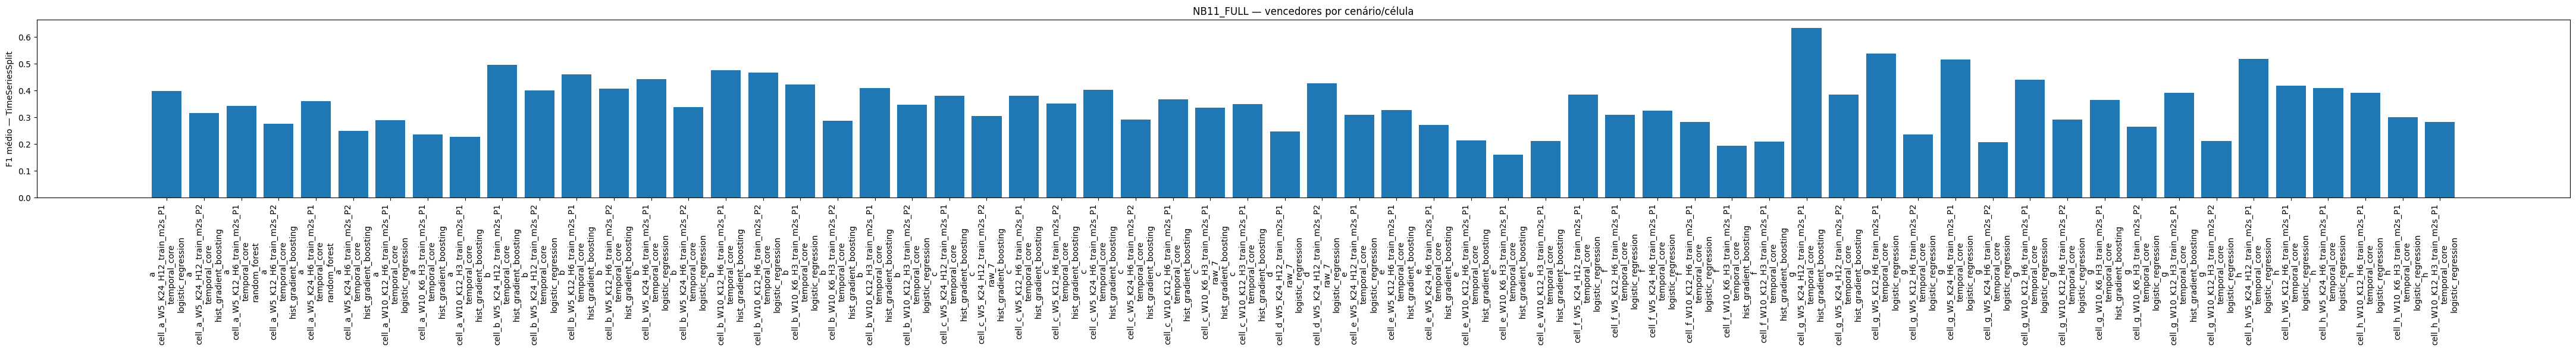

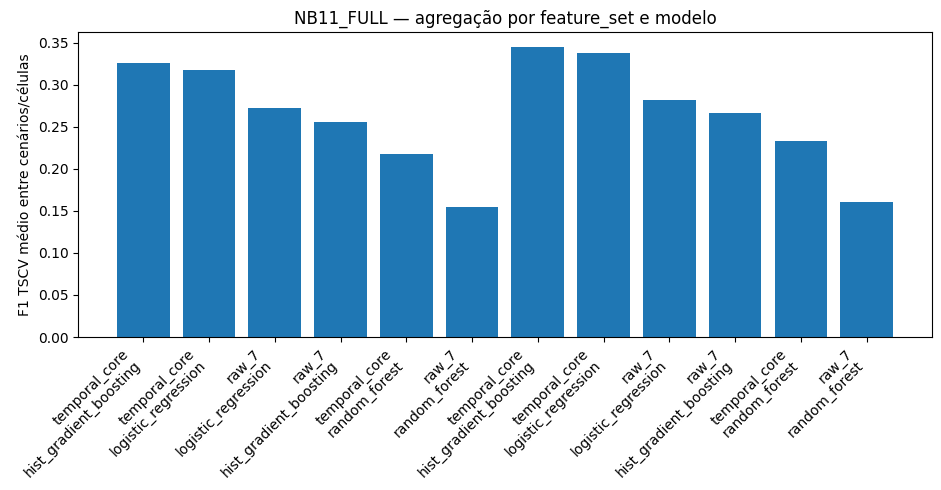


=== NB11_FULL — arquivos aggregate gerados ===


,artifact,path,exists
0,metrics_tscv_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
1,metrics_fixed_split_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
2,metrics_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
3,metrics_aggregate,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
4,baselines_all_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
5,baselines_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
6,feature_set_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
7,calibration_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
8,calibration_curve_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
9,lead_time_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True



=== NB11_FULL — resumo por célula ===


,cell_id,n_scenarios_evaluated,n_scenario_failures,n_metric_rows_tscv,n_metric_rows_fixed,n_model_input_rows
0,a,9,0,252,54,58634
1,b,12,0,294,72,71366
2,c,9,0,270,54,57812
3,d,2,0,36,12,16745
4,e,6,0,180,36,35565
5,f,6,0,180,36,33430
6,g,12,0,324,72,68993
7,h,6,0,180,36,31548



=== NB11_FULL — validações de piloto ===


...

,cell_id,n_cenarios,n_linhas,n_modelable_scenarios,min_pos_train,min_pos_test,median_pos_test,max_pos_test,n_descriptive_scenarios,cell_modelability_status
0,a,9,9,7,181,25,49.0,144,2,modelavel_em_ao_menos_um_cenario
1,b,12,12,10,108,24,63.0,147,2,modelavel_em_ao_menos_um_cenario
2,c,9,9,7,219,26,51.0,174,2,modelavel_em_ao_menos_um_cenario
3,d,2,2,0,347,12,12.5,13,2,descritiva_em_todos_os_cenarios
4,e,6,6,4,136,25,60.5,136,2,modelavel_em_ao_menos_um_cenario
5,f,6,6,6,208,42,106.0,231,0,modelavel_em_ao_menos_um_cenario
6,g,12,12,12,50,82,179.0,490,0,modelavel_em_ao_menos_um_cenario
7,h,6,6,6,297,69,171.5,384,0,modelavel_em_ao_menos_um_cenario



=== NB11_FULL — escopos do macro agregado ===


,aggregation_scope,n_rows,present
0,all_cells_including_descriptive,6,True
1,modelable_only,6,True



=== NB11_FULL — vencedor global ===
{
  "cell_id": "g",
  "scenario_label": "cell_g_W5_K24_H12_train_m2s_P1",
  "feature_set": "temporal_core",
  "model": "hist_gradient_boosting",
  "f1_tscv_mean": 0.633126396741871,
  "f1_tscv_std": 0.12896706890992332,
  "recall_tscv_mean": 0.6697141621563212,
  "recall_tscv_std": 0.11241114808846715,
  "precision_tscv_mean": 0.60812823052351,
  "precision_tscv_std": 0.14788615908676553,
  "roc_auc_tscv_mean": 0.8125826398984195,
  "average_precision_tscv_mean": 0.6627258180392973,
  "brier_tscv_mean": 0.1542739671943742,
  "n_features": 14,
  "features": [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding"
  ],
  "aggregation_scope": "modelable_only",
  "status_modelagem": "modelavel",
  "is_modelable": true,
  "n_positivos_train": 1640,
  "

,relative_path,size_bytes,sha256
154,cell_g/11_FULL_scores_raw_cell_g.parquet,623111,ca368dc7e285cc6ea67648bf27f3b75563228b2f333cc5...
155,cell_g/11_FULL_sequence_input_features_cell_g....,3435870,a04370a770aa1588f589402302f499454f2bc696f12001...
156,cell_h/11_FULL_baselines_all_cell_h.csv,146910,6af4e45ecfc59927419f11f7220a6e5465a0bd71275e25...
157,cell_h/11_FULL_baselines_summary_cell_h.csv,39874,cf8bc1794937b665cff7592990a27a425781adb5bf9ac7...
158,cell_h/11_FULL_calibration_curve_cell_h.csv,62836,ce7b26d3de9fd9c848b17830cbc578f91329b32943769b...
159,cell_h/11_FULL_calibration_summary_cell_h.csv,5218,a0e37599882ff2d612156c0d94a11af727485f18ec4413...
160,cell_h/11_FULL_episode_anticipation_cell_h.csv,81974,642bd8c1654d0ef01cc9232da4b3bed7f10519d06aef8f...
161,cell_h/11_FULL_feature_set_summary_cell_h.csv,765,4e19cbdb8827de9981fe72e27a2f4c7af343bf8a46e8b3...
162,cell_h/11_FULL_feature_sets_cell_h.json,6469,3089d6684182779efa75b52df9739a0580b330d811c195...
163,cell_h/11_FULL_lead_time_summary_cell_h.csv,4231,5ea8afc3c6a02579cd14dbbb13c6bd81e886ae1e20b151...


In [1]:
# ============================================================
# NB11_FULL — Baselines Temporais e Modelos Supervisionados por célula
# Pipeline PPCOMP/DM — ramo _FULL
#
# Versão revisada:
#   0. v11: preserva modelabilidade no resumo dos baselines.
#   1. Baselines também no TimeSeriesSplit.
#   2. Comparação entre conjuntos de features.
#   3. Features temporais causais reconstruídas quando ausentes.
#   4. Lead time com episódios avaliáveis.
#   5. Registro de recomendação defensiva para NB13/LSTM.
#   6. Inclusão de baseline temporal EWMA causal sobre fail_rate.
#   7. Gate de modelabilidade/descritiva por célula/cenário.
#   8. Macro agregado com e sem células descritivas.
# ============================================================


# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import sys
import json
import math
import random
import shutil
import hashlib
import subprocess
import importlib
import warnings
import difflib
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC_REFERENCE = 0.80  # referência apenas para validar o corte herdado; não rederivar split por fração
DEFAULT_THRESHOLD = 0.50
MIN_TSCV_SPLITS = 2

# Baseline temporal trivial adicional: EWMA causal do fail_rate.
# A regra operacional usa apenas dados do treino para definir o limiar
# e mantém a recorrência do EWMA de forma causal ao entrar no teste.
# Métodos aceitos: "m2s" = média_treino + 2*desvio_treino; "p95" = percentil 95 do treino.
EWMA_ALPHA = 0.30
EWMA_THRESHOLD_METHOD = "m2s"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB11_FULL iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================

# ============================================================
# 1. Bootstrap, caminhos oficiais _FULL e travas de herança
# ============================================================

if not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
else:
    print("[Bootstrap] Google Drive já montado.")

MYDRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_ROOT = MYDRIVE_ROOT / "Mestrado"
REPO_DIR = DRIVE_ROOT / "PPCOMP_DM"
NOTEBOOKS_DIR = MYDRIVE_ROOT / "Colab Notebooks"
CANONICAL_NOTEBOOK = NOTEBOOKS_DIR / "11_model_baselines.ipynb"
FULL_NOTEBOOK = NOTEBOOKS_DIR / "11_model_baselines_FULL.ipynb"
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    print(f"[Bootstrap] Clonando repositório em: {REPO_DIR}")
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)

os.chdir(str(REPO_DIR))
repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.insert(0, repo_str)
importlib.invalidate_caches()

FULL_CELLS = list("abcdefgh")
ACTIVE_CELLS = FULL_CELLS[:]  # Para piloto: ACTIVE_CELLS = ["a"]
# ACTIVE_CELLS = ["a"]

FULL_MODEL_FACING_PARQUET = (
    DRIVE_ROOT
    / "02-datasets"
    / "99-full"
    / "03-model-facing"
    / "window_5min_series_allcells_model_facing_000000000000.parquet"
)
CANONICAL_WINDOW_5MIN_SERIES = DRIVE_ROOT / "02-datasets" / "03-features" / "window_5min_series.parquet"

FULL_REPORTS_DIR = DRIVE_ROOT / "04-reports" / "99_FULL_downstream"
STAGE04_DIR = FULL_REPORTS_DIR / "04_FULL_episodes"
STAGE10_DIR = FULL_REPORTS_DIR / "10_FULL_threshold_diagnostics"
STAGE11_DIR = FULL_REPORTS_DIR / "11_FULL_model_baselines"
AGGREGATE_DIR = STAGE11_DIR / "aggregate"
FIGURES_DIR = AGGREGATE_DIR / "figures"
FIGURES_BY_CELL_DIR = AGGREGATE_DIR / "figures_by_cell"

# Gate metodológico exigido pela estratégia _FULL v1.5.
# O NB11_FULL consome o gate oficial do NB04_FULL quando disponível e,
# adicionalmente, recalcula os positivos train/test a partir do corte herdado
# para cada cenário efetivamente modelado.
MIN_TRAIN_POSITIVES_FOR_MODELING = 30
MIN_TEST_POSITIVES_FOR_MODELING = 30
MODELABILITY_GATE_DF = None
MODELABILITY_GATE_PATH = None

for p in [FULL_REPORTS_DIR, STAGE11_DIR, AGGREGATE_DIR, FIGURES_DIR, FIGURES_BY_CELL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD              :", Path.cwd())
print("DRIVE_ROOT       :", DRIVE_ROOT)
print("STAGE04_DIR      :", STAGE04_DIR)
print("STAGE10_DIR      :", STAGE10_DIR)
print("STAGE11_DIR      :", STAGE11_DIR)
print("AGGREGATE_DIR    :", AGGREGATE_DIR)
print("ACTIVE_CELLS     :", ACTIVE_CELLS)

assert "03-features" not in str(FULL_REPORTS_DIR), "FULL_REPORTS_DIR não pode apontar para 03-features."
assert FULL_MODEL_FACING_PARQUET != CANONICAL_WINDOW_5MIN_SERIES, "Entrada FULL não pode ser a série do protótipo Kaggle ajustado."
assert STAGE10_DIR.exists(), f"Artefatos NB10_FULL não encontrados: {STAGE10_DIR}"
assert STAGE11_DIR.exists(), f"Diretório de saída NB11_FULL indisponível: {STAGE11_DIR}"

CANONICAL_TEMPORAL_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]
temporal_core = CANONICAL_TEMPORAL_CORE[:]
assert len(temporal_core) == 14
assert temporal_core == CANONICAL_TEMPORAL_CORE

if FULL_MODEL_FACING_PARQUET.exists():
    df_cells_check = pd.read_parquet(FULL_MODEL_FACING_PARQUET, columns=["cell_id"])
    observed_cells = sorted(df_cells_check["cell_id"].dropna().astype(str).unique().tolist())
    assert observed_cells == FULL_CELLS, f"cell_id inesperado no Parquet FULL: {observed_cells}"
else:
    print(f"[NB11_FULL] Aviso: Parquet model-facing FULL não encontrado para checagem leve: {FULL_MODEL_FACING_PARQUET}")

# Sem backup de artefatos do protótipo Kaggle ajustado: o NB11_FULL grava apenas sob 99_FULL_downstream/11_FULL_model_baselines.
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")


def log(msg: str) -> None:
    print(f"[NB11_FULL_model_baselines] {msg}")



def _first_existing_col(df: pd.DataFrame, candidates: list[str]):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _normalize_status_modelagem(value) -> str | None:
    """
    Normaliza o status do gate de modelabilidade.

    Importante para o ramo FULL:
    - status com PENDING/PENDENTE não é veto; significa que o NB04 detectou suporte
      episódico, mas ainda não podia decidir a modelabilidade supervisionada antes do NB06/NB11.
    - "descritiva" só é veto quando aparece explicitamente como descritiva/insuficiente/sem suporte.
    """
    if value is None or pd.isna(value):
        return None
    raw = str(value).strip()
    s = raw.lower()
    s = (
        s.replace("á", "a")
         .replace("à", "a")
         .replace("ã", "a")
         .replace("â", "a")
         .replace("é", "e")
         .replace("ê", "e")
         .replace("í", "i")
         .replace("ó", "o")
         .replace("ô", "o")
         .replace("õ", "o")
         .replace("ú", "u")
         .replace("ç", "c")
    )

    # Estados provisórios/pendentes: não vetam o NB11; o status efetivo será decidido pelas contagens
    # supervisionadas calculadas no próprio cenário do NB11.
    if "pending" in s or "pendente" in s or "pending_nb06" in s:
        return "pendente"

    # Vetos explícitos. Evita classificar textos de justificativa com a palavra "supervisionada"
    # como modeláveis.
    if "descrit" in s or "limita" in s or "insuf" in s or "sem_suporte" in s or "no_support" in s:
        return "descritiva"

    if "modelavel" in s or "modelable" in s:
        return "modelavel"

    return None



def load_modelability_gate() -> pd.DataFrame:
    """
    Lê o gate oficial do NB04_FULL, quando disponível.

    O arquivo esperado é 04_FULL_modelability_gate_by_cell.csv no aggregate do NB04.
    A função aceita variações controladas de nome apenas para tolerar execuções anteriores.
    """
    global MODELABILITY_GATE_DF, MODELABILITY_GATE_PATH

    if MODELABILITY_GATE_DF is not None:
        return MODELABILITY_GATE_DF

    candidates = [
        STAGE04_DIR / "aggregate" / "04_FULL_modelability_gate_by_cell.csv",
        STAGE04_DIR / "aggregate" / "04_FULL_modelability_gate_by_cell_scenario.csv",
        STAGE04_DIR / "aggregate" / "04_FULL_episode_summary_by_cell.csv",
        STAGE04_DIR / "aggregate" / "04_FULL_detect_episodes_summary_by_cell.csv",
    ]

    for path in candidates:
        if path.exists():
            df_gate = pd.read_csv(path)
            MODELABILITY_GATE_PATH = path

            if "cell_id" in df_gate.columns:
                df_gate["cell_id"] = df_gate["cell_id"].astype(str).str.lower().str.replace("cell_", "", regex=False)

            if "status_modelagem" not in df_gate.columns:
                train_col = _first_existing_col(df_gate, ["n_positivos_train", "n_positive_train", "positivos_train", "train_positives"])
                test_col = _first_existing_col(df_gate, ["n_positivos_test", "n_positive_test", "positivos_test", "test_positives"])
                if train_col and test_col:
                    ntr = pd.to_numeric(df_gate[train_col], errors="coerce").fillna(0)
                    nte = pd.to_numeric(df_gate[test_col], errors="coerce").fillna(0)
                    df_gate["status_modelagem"] = np.where(
                        (ntr >= MIN_TRAIN_POSITIVES_FOR_MODELING) & (nte >= MIN_TEST_POSITIVES_FOR_MODELING),
                        "modelavel",
                        "descritiva",
                    )

            if "status_modelagem" in df_gate.columns:
                # Preserva o valor bruto do NB04 e cria a versão normalizada.
                # Estados pendentes/unknown não podem virar veto descritivo por fillna.
                df_gate["status_modelagem_nb04_raw"] = df_gate["status_modelagem"]
                df_gate["status_modelagem_nb04_normalized"] = df_gate["status_modelagem"].map(_normalize_status_modelagem)
                df_gate["status_modelagem"] = df_gate["status_modelagem_nb04_normalized"]

            log(f"Gate de modelabilidade carregado: {path}")
            MODELABILITY_GATE_DF = df_gate
            return MODELABILITY_GATE_DF

    log("Aviso: gate oficial do NB04_FULL não encontrado; NB11_FULL derivará status_modelagem pelos positivos train/test do corte herdado.")
    MODELABILITY_GATE_DF = pd.DataFrame()
    return MODELABILITY_GATE_DF


def infer_modelability_by_counts(n_positivos_train: int, n_positivos_test: int) -> tuple[str, str]:
    reasons = []
    if n_positivos_train < MIN_TRAIN_POSITIVES_FOR_MODELING:
        reasons.append(f"n_positivos_train={n_positivos_train} < {MIN_TRAIN_POSITIVES_FOR_MODELING}")
    if n_positivos_test < MIN_TEST_POSITIVES_FOR_MODELING:
        reasons.append(f"n_positivos_test={n_positivos_test} < {MIN_TEST_POSITIVES_FOR_MODELING}")
    if reasons:
        return "descritiva", "; ".join(reasons)
    return "modelavel", "suporte mínimo train/test atendido"


def get_gate_row_for_scenario(cell_id: str, scenario_label: str):
    gate = load_modelability_gate()
    if gate.empty or "cell_id" not in gate.columns:
        return None

    g = gate[gate["cell_id"].astype(str).str.lower().str.replace("cell_", "", regex=False) == str(cell_id).lower()].copy()
    if g.empty:
        return None

    scenario_col = _first_existing_col(g, ["scenario_label", "scenario_id", "scenario"])
    if scenario_col:
        exact = g[g[scenario_col].astype(str) == str(scenario_label)]
        if not exact.empty:
            return exact.iloc[0]

    # Se o gate oficial for apenas por célula, aplica a classificação da célula
    # como restrição metodológica geral. Os n_positivos_* continuam derivados por cenário.
    return g.iloc[0]


def compute_modelability_info(scenario: dict, df_supervised: pd.DataFrame) -> dict:
    """
    Calcula e propaga o status modelável/descritiva por cenário.

    Regras v7:
    - o gate do NB04 é preservado como evidência upstream;
    - status NB04 pendente (ex.: HAS_EPISODE_SUPPORT_PENDING_NB06_LABELS) é consultivo,
      não veto, porque o NB04 ainda não tinha o alvo supervisionado do NB11;
    - a decisão efetiva do NB11 usa n_positivos_train/test calculados sobre o alvo de antecipação
      supervisionado e o corte herdado;
    - veto NB04 explícito ('descritiva' por insuficiência real) ainda torna o cenário descritivo;
    - cenários descritivos continuam reportados, mas ficam fora do macro primário modelable_only.
    """
    scenario_label = get_scenario_label(scenario)
    cell_id = str(scenario.get("cell_id", CURRENT_CELL_ID)).lower().replace("cell_", "")
    cutoff_idx = int(scenario["train_cutoff_idx"])

    if "row_position" not in df_supervised.columns:
        raise AssertionError(f"{scenario_label}: row_position ausente ao calcular modelability; abortar.")

    row_pos = pd.to_numeric(df_supervised["row_position"], errors="coerce")
    if row_pos.isna().any():
        raise ValueError(f"{scenario_label}: row_position contém NaN no cálculo de modelability.")

    y = pd.to_numeric(df_supervised["y_nb11"], errors="coerce").fillna(0).clip(0, 1).astype(int)
    train_mask = row_pos.astype(int) < cutoff_idx
    test_mask = ~train_mask

    n_train = int(train_mask.sum())
    n_test = int(test_mask.sum())
    n_positivos_train = int(y[train_mask].sum())
    n_positivos_test = int(y[test_mask].sum())

    count_status, count_reason = infer_modelability_by_counts(n_positivos_train, n_positivos_test)

    gate_row = get_gate_row_for_scenario(cell_id, scenario_label)
    official_status = None
    official_status_raw = None
    official_reason = None
    source = "derived_from_nb11_inherited_cutoff"
    official_gate_pending = False
    official_gate_veto = False

    if gate_row is not None:
        source = "nb04_gate_consultive_plus_nb11_counts"
        if "status_modelagem_nb04_raw" in gate_row.index:
            official_status_raw = gate_row.get("status_modelagem_nb04_raw")
        elif "status_modelagem" in gate_row.index:
            official_status_raw = gate_row.get("status_modelagem")

        if "status_modelagem_nb04_normalized" in gate_row.index and not pd.isna(gate_row.get("status_modelagem_nb04_normalized")):
            official_status = str(gate_row.get("status_modelagem_nb04_normalized"))
        else:
            official_status = _normalize_status_modelagem(official_status_raw)

        for c in ["justificativa", "justification", "modelability_reason", "reason"]:
            if c in gate_row.index and not pd.isna(gate_row[c]):
                official_reason = str(gate_row[c])
                break

    official_gate_pending = bool(official_status == "pendente")
    official_gate_veto = bool(official_status == "descritiva")

    if official_gate_veto:
        status = "descritiva"
    elif count_status == "descritiva":
        status = "descritiva"
    elif count_status == "modelavel":
        # Gate NB04 pendente/ausente não veta; o NB11 já tem o alvo supervisionado.
        status = "modelavel"
    elif official_status == "modelavel":
        status = "modelavel"
    else:
        status = count_status

    reasons = []
    if official_status_raw is not None:
        reasons.append(f"gate_nb04_raw={official_status_raw}")
    if official_status is not None:
        reasons.append(f"gate_nb04_normalized={official_status}")
    if official_gate_pending:
        reasons.append("gate_nb04_consultivo=pendente_nao_veta_nb11")
    if official_gate_veto:
        reasons.append("gate_nb04_veto=descritiva")
    if official_reason:
        reasons.append(f"gate_reason={official_reason}")
    reasons.append(f"nb11_counts={count_reason}")

    return {
        "cell_id": cell_id,
        "scenario_label": scenario_label,
        "status_modelagem": status,
        "is_modelable": bool(status == "modelavel"),
        "modelability_source": source,
        "modelability_gate_path": str(MODELABILITY_GATE_PATH) if MODELABILITY_GATE_PATH else "",
        "modelability_reason": " | ".join(reasons),
        "status_modelagem_nb04_raw": "" if official_status_raw is None else str(official_status_raw),
        "status_modelagem_nb04_normalized": "" if official_status is None else str(official_status),
        "status_modelagem_nb11_counts": count_status,
        "is_modelable_by_nb11_counts": bool(count_status == "modelavel"),
        "official_gate_pending": official_gate_pending,
        "official_gate_veto": official_gate_veto,
        "min_train_positives_for_modeling": int(MIN_TRAIN_POSITIVES_FOR_MODELING),
        "min_test_positives_for_modeling": int(MIN_TEST_POSITIVES_FOR_MODELING),
        "n_rows_supervised": int(len(df_supervised)),
        "n_train": n_train,
        "n_test": n_test,
        "n_positivos_train": n_positivos_train,
        "n_positivos_test": n_positivos_test,
    }



def attach_modelability_columns(df: pd.DataFrame, info: dict) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    cols = [
        "status_modelagem",
        "is_modelable",
        "modelability_source",
        "modelability_reason",
        "status_modelagem_nb04_raw",
        "status_modelagem_nb04_normalized",
        "status_modelagem_nb11_counts",
        "is_modelable_by_nb11_counts",
        "official_gate_pending",
        "official_gate_veto",
        "n_positivos_train",
        "n_positivos_test",
        "min_train_positives_for_modeling",
        "min_test_positives_for_modeling",
    ]
    for col in cols:
        if col in info:
            out[col] = info[col]
    return out




def coerce_binary_target(series, context: str, fill_missing: bool = False) -> pd.Series:
    """
    Converte alvo binário para int sem quebrar quando NB10_FULL traz NaN/inf em
    janelas inelegíveis, bordas de horizonte ou estados fora da tarefa supervisionada.

    - Quando fill_missing=True, valores não finitos são preenchidos com 0 antes do
      filtro supervisionado. Isso é seguro apenas para quadros completos, pois DURING
      e cauda sem horizonte são removidos/ignorados depois.
    - Quando fill_missing=False, qualquer NaN remanescente é erro estrutural.
    """
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    n_bad = int(s.isna().sum())
    if n_bad:
        if not fill_missing:
            raise ValueError(f"{context}: alvo contém {n_bad} valores não finitos em linhas supervisionadas.")
        log(f"Aviso: {context}: {n_bad} valores não finitos no alvo; preenchendo como 0 antes do filtro supervisionado.")
        s = s.fillna(0)
    return s.clip(lower=0, upper=1).round().astype(int)


def sanitize_row_position_inplace(df: pd.DataFrame, scenario_label: str) -> pd.DataFrame:
    """
    Garante row_position inteiro para aplicação do corte herdado.

    Se row_position vier totalmente/parcialmente nulo do upstream, deriva a posição
    ordinal a partir de bucket_id dentro do cenário já filtrado. Isso não recalcula o
    split por fração; apenas recompõe a coluna ordinal necessária para aplicar o
    train_cutoff_idx herdado do NB04/NB06.
    """
    if "row_position" not in df.columns:
        raise AssertionError(f"row_position ausente em states para {scenario_label}; abortar, não rederivar split por fração.")

    row_pos = pd.to_numeric(df["row_position"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    n_bad = int(row_pos.isna().sum())

    if n_bad:
        if "bucket_id" not in df.columns:
            raise ValueError(f"{scenario_label}: row_position tem {n_bad} valores não finitos e bucket_id ausente para recompor ordinal.")
        ordered_idx = df.sort_values("bucket_id").index
        derived = pd.Series(np.arange(len(df), dtype=int), index=ordered_idx).reindex(df.index)
        log(f"Aviso: {scenario_label}: {n_bad} row_position não finitos; recompondo pela ordem de bucket_id, sem alterar train_cutoff_idx.")
        row_pos = row_pos.fillna(derived)

    if row_pos.isna().any():
        raise ValueError(f"{scenario_label}: row_position ainda contém valores não finitos após saneamento.")

    df = df.copy()
    df["row_position"] = row_pos.astype(int)
    return df


# ============================================================
# 2. Entradas do NB10_FULL
# ============================================================

# O NB10_FULL grava artefatos por célula. O NB11_FULL carrega cada célula
# separadamente, executa a modelagem como réplica independente e só depois
# consolida tabelas aggregate com cell_id preservado.
# 3. Funções gerais
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)



def json_ready(obj):
    """Converte objetos NumPy/Pandas/Path para JSON seguro."""
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [json_ready(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        val = float(obj)
        return None if np.isnan(val) else val
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def build_artifact_manifest(root_dir: Path, out_file: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(root_dir.rglob("*")):
        if not p.is_file():
            continue
        if p == out_file:
            continue
        rows.append({
            "relative_path": str(p.relative_to(root_dir)).replace("\\", "/"),
            "size_bytes": int(p.stat().st_size),
            "sha256": sha256_file(p),
        })
    df = pd.DataFrame(rows)
    df.to_csv(out_file, index=False, encoding="utf-8")
    return df


def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8")


def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def compute_ece(y_true, y_score, n_bins=10):
    """
    Expected Calibration Error simples.
    Usado como diagnóstico da calibração.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if len(y_true) == 0:
        return np.nan

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left = bins[i]
        right = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_score >= left) & (y_score <= right)
        else:
            mask = (y_score >= left) & (y_score < right)

        if mask.sum() == 0:
            continue

        acc_bin = y_true[mask].mean()
        conf_bin = y_score[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc_bin - conf_bin)

    return float(ece)


def build_calibration_curve_df(
    y_true,
    score,
    stage,
    scenario_label,
    feature_set_name,
    model_name,
    n_bins=10,
):
    """
    Materializa a curva empírica de calibração ponto a ponto.

    Este artefato complementa 11_calibration_summary.csv: o resumo decide se a
    calibração melhorou Brier/ECE; a curva alimenta diretamente a Figura 7 do NB15.
    """
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)

    mask = np.isfinite(score)
    y_true = y_true[mask]
    score = np.clip(score[mask], 0.0, 1.0)

    if len(y_true) == 0:
        return pd.DataFrame(columns=[
            "scenario_label",
            "feature_set",
            "model",
            "calibration_stage",
            "bin",
            "bin_left",
            "bin_right",
            "mean_pred",
            "frac_pos",
            "count",
        ])

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(score, bins, right=True)
    bin_id = np.clip(bin_id, 1, n_bins)

    rows = []
    for b in range(1, n_bins + 1):
        m = bin_id == b
        if m.sum() == 0:
            continue
        rows.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set_name,
            "model": model_name,
            "calibration_stage": stage,
            "bin": int(b),
            "bin_left": float(bins[b - 1]),
            "bin_right": float(bins[b]),
            "mean_pred": float(score[m].mean()),
            "frac_pos": float(y_true[m].mean()),
            "count": int(m.sum()),
        })

    return pd.DataFrame(rows)


def binary_metrics(y_true, y_score, threshold=0.5):
    """
    Métricas binárias padronizadas para modelos e baselines.
    y_score pode ser probabilidade, escore ou saída binária.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "threshold": threshold,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "average_precision": np.nan,
            "brier": np.nan,
            "tn": 0,
            "fp": 0,
            "fn": 0,
            "tp": 0,
        }

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_auc(y_true, y_score)) if not np.isnan(safe_auc(y_true, y_score)) else np.nan,
        "average_precision": float(safe_ap(y_true, y_score)) if not np.isnan(safe_ap(y_true, y_score)) else np.nan,
        "brier": float(safe_brier(y_true, y_score)) if not np.isnan(safe_brier(y_true, y_score)) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)

    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


def infer_scenario_column(df: pd.DataFrame):
    candidates = [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    raise ValueError("Não foi possível identificar a coluna de cenário.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = [
        "start_bucket_id",
        "episode_start_bucket_id",
        "start_bucket",
        "bucket_start",
        "start",
    ]

    end_candidates = [
        "end_bucket_id",
        "episode_end_bucket_id",
        "end_bucket",
        "bucket_end",
        "end",
    ]

    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)

    if start_col is None or end_col is None:
        raise ValueError(
            "Não foi possível identificar colunas de início/fim dos episódios."
        )

    return start_col, end_col


def scenario_to_dict_list(obj):
    """
    Normaliza o JSON do NB10 para lista de cenários.
    """
    if isinstance(obj, list):
        return obj

    if isinstance(obj, dict):
        for key in [
            "advanced_to_nb11",
            "scenarios",
            "advanced_scenarios",
            "items",
        ]:
            if key in obj and isinstance(obj[key], list):
                return obj[key]

        if all(isinstance(v, dict) for v in obj.values()):
            out = []
            for k, v in obj.items():
                vv = dict(v)
                vv.setdefault("scenario_label", k)
                out.append(vv)
            return out

    raise ValueError("Formato não reconhecido para 10_scenario_advanced_to_nb11.json")


def get_scenario_label(scen):
    for k in [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]:
        if k in scen:
            return str(scen[k])

    raise ValueError(f"Cenário sem identificador reconhecido: {scen}")


def get_first_available(dct, keys, default=None):
    for k in keys:
        if k in dct and dct[k] is not None:
            return dct[k]
    return default


def parse_int_from_label(label, token, default=None):
    try:
        parts = str(label).split("_")
        for p in parts:
            if p.startswith(token):
                return int(p.replace(token, ""))
    except Exception:
        return default
    return default


# ============================================================

# ============================================================
# 4. Carregamento dos artefatos do NB10_FULL por célula
# ============================================================


def resolve_nb10_cell_files(cell_id: str) -> dict:
    cell_dir = STAGE10_DIR / f"cell_{cell_id}"
    files = {
        "advanced_json": cell_dir / f"10_FULL_advanced_to_nb11_cell_{cell_id}.json",
        "states_parquet": cell_dir / f"10_FULL_scenario_series_states_cell_{cell_id}.parquet",
        "episodes_parquet": cell_dir / f"10_FULL_scenario_episodes_cell_{cell_id}.parquet",
        "decisions_csv": cell_dir / f"10_FULL_scenario_decisions_cell_{cell_id}.csv",
    }
    missing = [str(p) for p in files.values() if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Arquivos esperados do NB10_FULL não encontrados para cell_{cell_id}:\n" + "\n".join(missing)
        )
    return files


def load_nb10_cell_inputs(cell_id: str) -> dict:
    files = resolve_nb10_cell_files(cell_id)
    advanced_raw = read_json(files["advanced_json"])
    advanced_scenarios = scenario_to_dict_list(advanced_raw)

    df_states = pd.read_parquet(files["states_parquet"])
    df_episodes = pd.read_parquet(files["episodes_parquet"])
    df_decisions = pd.read_csv(files["decisions_csv"])

    if "cell_id" not in df_states.columns:
        df_states["cell_id"] = cell_id
    if not df_episodes.empty and "cell_id" not in df_episodes.columns:
        df_episodes["cell_id"] = cell_id
    df_decisions["cell_id"] = df_decisions.get("cell_id", cell_id)

    observed_states = sorted(df_states["cell_id"].dropna().astype(str).unique().tolist())
    assert observed_states == [cell_id], f"states NB10_FULL da cell_{cell_id} contém células inesperadas: {observed_states}"
    if not df_episodes.empty:
        observed_eps = sorted(df_episodes["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_eps == [cell_id], f"episodes NB10_FULL da cell_{cell_id} contém células inesperadas: {observed_eps}"

    for scen in advanced_scenarios:
        scen.setdefault("cell_id", cell_id)
        scen.setdefault("scenario_label", get_scenario_label(scen))
        assert str(scen.get("cell_id")) == str(cell_id), f"Cenário com cell_id divergente: {scen}"
        assert "train_cutoff_idx" in scen and "train_cutoff_bucket_id" in scen, (
            f"NB10_FULL sem corte herdado no cenário {get_scenario_label(scen)}: "
            "train_cutoff_idx e train_cutoff_bucket_id são obrigatórios; abortar, não recalcular por fração."
        )

    scenario_col_states = infer_scenario_column(df_states)
    scenario_col_episodes = infer_scenario_column(df_episodes) if not df_episodes.empty else scenario_col_states
    episode_start_col, episode_end_col = (None, None)
    if not df_episodes.empty:
        episode_start_col, episode_end_col = infer_episode_columns(df_episodes)

    return {
        "cell_id": cell_id,
        "files": files,
        "advanced_scenarios": advanced_scenarios,
        "df_states_all": df_states,
        "df_episodes_all": df_episodes,
        "df_decisions": df_decisions,
        "scenario_col_states": scenario_col_states,
        "scenario_col_episodes": scenario_col_episodes,
        "episode_start_col": episode_start_col,
        "episode_end_col": episode_end_col,
    }


# Variáveis globais preenchidas a cada célula por process_cell().
df_states_all = pd.DataFrame()
df_episodes_all = pd.DataFrame()
df_decisions = pd.DataFrame()
scenario_col_states = "scenario_id"
scenario_col_episodes = "scenario_id"
episode_start_col = "start_bucket_id"
episode_end_col = "end_bucket_id"
CURRENT_CELL_ID = None
# 5. Features temporais causais e conjuntos de features
# ============================================================

RAW_7_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_FAIL_count",
    "event_LOST_count",
]

TEMPORAL_CORE_FEATURES = RAW_7_FEATURES + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

TEMPORAL_FULL_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "mean_priority",
    "mean_req_cpus",
    "mean_req_mem",
    "req_cpus_presence_rate",
    "req_mem_presence_rate",
    "event_FAIL_count",
    "event_SCHEDULE_count",
    "event_FINISH_count",
    "event_ENABLE_count",
    "event_LOST_count",
    "event_EVICT_count",
    "event_KILL_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

FORBIDDEN_FEATURE_PATTERNS = [
    "target",
    "label",
    "state",
    "during",
    "before",
    "after",
    "critical",
    "episode",
    "future",
    "horizon",
    "bucket_start_us",
    "bucket_id",
    "time",
    "timestamp",
]

# v9: gate NB04 pendente consultivo + trava de comparabilidade efetiva.
# Não basta a constante CANONICAL_TEMPORAL_CORE ter 14 atributos;
# o conjunto realmente entregue ao modelo também precisa estar completo.
STRICT_CANONICAL_FEATURE_SETS = True
REQUIRED_EXACT_FEATURE_SETS = {
    "raw_7": RAW_7_FEATURES,
    "temporal_core": TEMPORAL_CORE_FEATURES,
}


def _numeric_available_columns(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]


def validate_effective_required_feature_sets(df: pd.DataFrame, context: str = "") -> None:
    """
    Valida os conjuntos efetivamente disponíveis no frame supervisionado.

    Motivo v8:
    - o parecer consolidado identificou que temporal_core estava sendo executado com 10/14;
    - raw_7 estava sendo executado com 3/7;
    - isso quebra a comparabilidade entre protótipo Kaggle ajustado e FULL.

    Portanto, se STRICT_CANONICAL_FEATURE_SETS=True, o NB11_FULL falha cedo e de forma clara
    quando NB05/NB06/NB10 não propagarem as colunas metodologicamente exigidas.
    """
    if not STRICT_CANONICAL_FEATURE_SETS:
        return

    problems = []
    for set_name, required_cols in REQUIRED_EXACT_FEATURE_SETS.items():
        present_numeric = _numeric_available_columns(df, required_cols)
        missing = [c for c in required_cols if c not in present_numeric]
        if missing or len(present_numeric) != len(required_cols):
            problems.append(
                f"{set_name}: efetivo={len(present_numeric)}/{len(required_cols)}; "
                f"faltantes_ou_nao_numericas={missing}"
            )

    if problems:
        prefix = f"{context}: " if context else ""
        raise AssertionError(
            prefix
            + "conjunto de features efetivo incompleto; corrigir propagação upstream "
            + "NB05/NB06/NB10 antes de selar o NB11_FULL. "
            + " | ".join(problems)
        )


def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    """
    Reconstrói features temporais causais a partir de fail_rate.

    Todas as operações usam apenas informação disponível até t
    ou anterior a t, preservando causalidade.
    """
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar features temporais causais.")

    df = df.sort_values("bucket_id").copy()

    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)

    rolling_window = max(int(round(60 / window_minutes)), 1)

    # Rolling com shift(1) para não usar o valor corrente na estatística histórica.
    df["rolling_mean_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )

    df["rolling_std_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=2)
        .std(ddof=0)
    )

    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)

    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)

    df["zscore_expanding"] = (
        (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    )

    temporal_cols = [
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change",
        "zscore_expanding",
    ]

    df[temporal_cols] = (
        df[temporal_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df


def validate_feature_list(cols):
    """
    Defesa adicional contra colunas com risco de vazamento.
    """
    bad = []

    for c in cols:
        lower = c.lower()

        if c == "fail_rate":
            continue

        if any(p in lower for p in FORBIDDEN_FEATURE_PATTERNS):
            bad.append(c)

    if bad:
        raise ValueError(f"Features com risco de vazamento detectadas: {bad}")


def build_feature_sets(df: pd.DataFrame, context: str = ""):
    """
    Constrói conjuntos de features disponíveis, evitando duplicatas.

    v8: antes de filtrar por disponibilidade, valida que os conjuntos de features definidos
    exigidos para comparabilidade foram efetivamente propagados até o frame do NB11.
    Isso evita executar silenciosamente temporal_core com 10/14 ou raw_7 com 3/7.
    """
    validate_effective_required_feature_sets(df, context=context)

    candidates = {
        "raw_7": _numeric_available_columns(df, RAW_7_FEATURES),
        "temporal_core": _numeric_available_columns(df, TEMPORAL_CORE_FEATURES),
        "temporal_full": _numeric_available_columns(df, TEMPORAL_FULL_FEATURES),
    }

    feature_sets = {}
    seen = set()

    for name, cols in candidates.items():
        if len(cols) == 0:
            continue

        validate_feature_list(cols)

        signature = tuple(cols)

        if signature in seen:
            continue

        seen.add(signature)
        feature_sets[name] = cols

    if not feature_sets:
        raise ValueError("Nenhum conjunto de features pôde ser construído.")

    return feature_sets


# ============================================================
# 6. Construção/validação do alvo supervisionado
# ============================================================

def ensure_target_column(df: pd.DataFrame, scenario: dict):
    """
    Garante coluna y_nb11 para antecipação.

    Prioriza alvos já produzidos pelo NB10.
    Se não houver, reconstrói a partir do estado DURING e do horizonte H.
    """
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
    ]

    df = df.copy()

    for c in target_candidates:
        if c in df.columns:
            # Primeiro restringe à tarefa supervisionada; só então exige alvo finito.
            # O NB10_FULL pode trazer NaN em DURING/AFTER ou na cauda sem horizonte.
            if "state" in df.columns:
                df = df[df["state"].isin(["NORMAL", "BEFORE"])].copy()

            for hcol in ["has_complete_horizon", "complete_horizon", "has_complete_horizon_nb11", "eligible_supervised"]:
                if hcol in df.columns:
                    h = df[hcol].fillna(False).astype(bool)
                    df = df[h].copy()

            df["y_nb11"] = coerce_binary_target(
                df[c],
                context=f"{get_scenario_label(scenario)}::{c}",
                fill_missing=False,
            )

            return df

    if "state" not in df.columns:
        raise ValueError(
            "Nenhuma coluna alvo encontrada e coluna 'state' ausente para reconstrução."
        )

    label = get_scenario_label(scenario)

    h_windows = int(
        get_first_available(
            scenario,
            ["h_windows", "H", "h", "horizon_windows"],
            parse_int_from_label(label, "H", default=12),
        )
    )

    df = df.sort_values("bucket_id").reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = (states == "DURING")

    y = np.zeros(len(df), dtype=int)

    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)

    df["y_nb11"] = y.astype(int)

    # Remove janelas sem horizonte futuro completo.
    df["has_complete_horizon_nb11"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb11"] = True

    df = df[
        df["state"].isin(["NORMAL", "BEFORE"])
        & df["has_complete_horizon_nb11"]
    ].copy()

    return df


# ============================================================
# 7. Baselines causais
# ============================================================

def get_train_m2s_threshold(scenario: dict, df_train: pd.DataFrame):
    """
    Recupera train_m2s do cenário.
    Se não existir no JSON, estima como média + 2 desvios no treino.
    """
    possible = [
        "train_m2s",
        "threshold_train_m2s",
        "limiar_train_m2s",
        "threshold_value",
        "threshold",
        "critical_threshold",
    ]

    val = get_first_available(scenario, possible, None)

    if val is not None:
        try:
            return float(val)
        except Exception:
            pass

    if "fail_rate" not in df_train.columns:
        raise ValueError("fail_rate ausente para estimar train_m2s.")

    return float(df_train["fail_rate"].mean() + 2.0 * df_train["fail_rate"].std(ddof=0))


def baseline_majority_zero(df_train, df_eval, threshold_value=None):
    return np.zeros(len(df_eval), dtype=float), {}


def baseline_recent_fail_rate(df_train, df_eval, threshold_value):
    """
    Baseline temporal ingênuo causal:
    alerta se fail_rate da janela anterior ultrapassa train_m2s.

    Para a primeira janela de teste, usa a última janela do treino como passado.
    """
    if len(df_train) > 0:
        bridge = pd.concat([df_train.tail(1), df_eval], ignore_index=True)
        prev_fail_rate = bridge["fail_rate"].shift(1).iloc[1:].values
    else:
        prev_fail_rate = df_eval["fail_rate"].shift(1).fillna(0.0).values

    scores = (prev_fail_rate >= threshold_value).astype(float)

    return scores, {
        "baseline_threshold": float(threshold_value),
    }


def baseline_lowered_threshold(df_train, df_eval, threshold_value):
    """
    Baseline de limiar rebaixado:
    alerta se fail_rate_t >= 0,5 * train_m2s.
    """
    lowered = 0.5 * threshold_value
    scores = (df_eval["fail_rate"].values >= lowered).astype(float)

    return scores, {
        "baseline_threshold": float(lowered),
    }


def baseline_zscore_causal(df_train, df_eval, threshold_value=None):
    """
    Baseline z-score causal:
    limiar definido no treino como p95 do zscore_expanding.
    """
    if "zscore_expanding" not in df_train.columns or "zscore_expanding" not in df_eval.columns:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "zscore_expanding_unavailable",
        }

    z_train = (
        df_train["zscore_expanding"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(z_train) == 0:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "zscore_train_empty",
        }

    z_thr = float(np.nanpercentile(z_train.values, 95))

    scores = (
        df_eval["zscore_expanding"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(-np.inf)
        .values >= z_thr
    ).astype(float)

    return scores, {
        "baseline_threshold": z_thr,
    }


def compute_ewma_fail_rate(values, alpha=EWMA_ALPHA):
    """
    Calcula EWMA causal sobre uma série de fail_rate.

    A atualização em t usa fail_rate_t e o estado acumulado até t-1:
        ewma_t = alpha * fail_rate_t + (1 - alpha) * ewma_{t-1}

    No contexto do NB11_FULL, isso é causal porque a previsão em t usa apenas
    informações observadas até a janela t.
    """
    values = (
        pd.Series(values, dtype="float64")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    if len(values) == 0:
        return np.array([], dtype=float)

    return values.ewm(alpha=float(alpha), adjust=False).mean().values


def ewma_threshold_from_train(ewma_train, method=EWMA_THRESHOLD_METHOD):
    """
    Define o limiar do baseline EWMA usando exclusivamente o conjunto de treino.

    method="m2s": média_treino(EWMA) + 2 * desvio_treino(EWMA)
    method="p95": percentil 95_treino(EWMA)
    """
    ewma_train = np.asarray(ewma_train, dtype=float)
    ewma_train = ewma_train[np.isfinite(ewma_train)]

    if len(ewma_train) == 0:
        return np.nan, {
            "ewma_train_mean": np.nan,
            "ewma_train_std": np.nan,
            "ewma_train_p95": np.nan,
        }

    mean_train = float(np.mean(ewma_train))
    std_train = float(np.std(ewma_train, ddof=0))
    p95_train = float(np.nanpercentile(ewma_train, 95))

    method = str(method).lower().strip()

    if method == "p95":
        threshold = p95_train
    elif method == "m2s":
        threshold = mean_train + 2.0 * std_train
    else:
        raise ValueError(
            "EWMA_THRESHOLD_METHOD inválido. Use 'm2s' ou 'p95'."
        )

    return float(threshold), {
        "ewma_train_mean": mean_train,
        "ewma_train_std": std_train,
        "ewma_train_p95": p95_train,
    }


def baseline_ewma_fail_rate_causal(df_train, df_eval, threshold_value=None):
    """
    Baseline temporal EWMA causal sobre fail_rate.

    Objetivo metodológico:
    - ficar entre a regra instantânea de fail_rate e modelos temporais não triviais;
    - suavizar ruído de janelas isoladas;
    - testar se a persistência temporal simples já antecipa janelas de risco;
    - manter interpretação operacional simples e barata.

    Procedimento:
    1. Calcula EWMA no treino.
    2. Define o limiar apenas no treino.
    3. Continua o EWMA no teste a partir do estado acumulado no treino.
    4. Emite alarme binário quando EWMA_t >= limiar.
    """
    if "fail_rate" not in df_train.columns or "fail_rate" not in df_eval.columns:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "fail_rate_unavailable_for_ewma",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        }

    train_fail = (
        df_train["fail_rate"]
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .reset_index(drop=True)
    )

    eval_fail = (
        df_eval["fail_rate"]
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .reset_index(drop=True)
    )

    if len(eval_fail) == 0:
        return np.array([], dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "eval_empty_for_ewma",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        }

    if len(train_fail) == 0:
        return np.zeros(len(eval_fail), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "train_empty_for_ewma",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        }

    ewma_train = compute_ewma_fail_rate(train_fail, alpha=EWMA_ALPHA)
    ewma_threshold, ewma_stats = ewma_threshold_from_train(
        ewma_train,
        method=EWMA_THRESHOLD_METHOD,
    )

    if not np.isfinite(ewma_threshold):
        return np.zeros(len(eval_fail), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "ewma_threshold_not_finite",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
            **ewma_stats,
        }

    # Mantém a memória temporal do EWMA ao passar do treino para o teste.
    combined_fail = pd.concat([train_fail, eval_fail], ignore_index=True)
    ewma_combined = compute_ewma_fail_rate(combined_fail, alpha=EWMA_ALPHA)
    ewma_eval = ewma_combined[len(train_fail):]

    scores = (ewma_eval >= ewma_threshold).astype(float)

    return scores, {
        "baseline_threshold": float(ewma_threshold),
        "baseline_score_type": "binary_alarm_from_causal_ewma_fail_rate",
        "ewma_alpha": float(EWMA_ALPHA),
        "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        **ewma_stats,
    }


BASELINES = {
    "majority_zero": baseline_majority_zero,
    "recent_fail_rate_train_m2s": baseline_recent_fail_rate,
    "lowered_threshold_0p5_train_m2s": baseline_lowered_threshold,
    "zscore_expanding_p95_train": baseline_zscore_causal,
    f"ewma_fail_rate_{EWMA_THRESHOLD_METHOD}_train": baseline_ewma_fail_rate_causal,
}


def get_inherited_split_mask(df: pd.DataFrame, scenario: dict):
    """
    Retorna máscaras train/test com base no corte herdado do NB04/NB06 via NB10_FULL.

    O split NÃO é rederivado por fração. Para cada cenário, usa row_position < train_cutoff_idx.
    Se row_position estiver ausente, aborta; isso evita drift de fronteira e contradição interna.
    """
    scenario_label = get_scenario_label(scenario)
    if "train_cutoff_idx" not in scenario or "train_cutoff_bucket_id" not in scenario:
        raise AssertionError(
            f"NB10_FULL sem corte herdado no cenário {scenario_label}: abortar, não recalcular por fração."
        )
    if "row_position" not in df.columns:
        raise AssertionError(
            f"row_position ausente em {scenario_label}; abortar, não usar iloc/fração para split."
        )

    cutoff_idx = int(scenario["train_cutoff_idx"])
    row_pos = pd.to_numeric(df["row_position"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    if row_pos.isna().any():
        raise ValueError(
            f"{scenario_label}: row_position contém {int(row_pos.isna().sum())} valores não finitos após preparação."
        )
    row_pos = row_pos.astype(int)
    train_mask = row_pos < cutoff_idx
    test_mask = ~train_mask

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        raise ValueError(
            f"Split herdado vazio em {scenario_label}: train={int(train_mask.sum())}, test={int(test_mask.sum())}."
        )

    if "temporal_partition" in df.columns:
        expected = np.where(train_mask, "train", "test")
        observed = df["temporal_partition"].astype(str).str.lower().to_numpy()
        comparable = np.isin(observed, ["train", "test"])
        if comparable.any():
            assert (observed[comparable] == expected[comparable]).all(), (
                f"temporal_partition diverge de train_cutoff_idx em {scenario_label}."
            )

    ratio = float(cutoff_idx / (row_pos.max() + 1))
    assert abs(ratio - FIXED_TRAIN_FRAC_REFERENCE) < 0.01, (
        f"Corte herdado não preserva 80/20 em {scenario_label}: ratio={ratio:.4f}."
    )
    return train_mask.to_numpy(), test_mask.to_numpy(), cutoff_idx


def split_train_test_inherited(df: pd.DataFrame, scenario: dict):
    train_mask, test_mask, cutoff_idx = get_inherited_split_mask(df, scenario)
    df_train = df.loc[train_mask].copy()
    df_test = df.loc[test_mask].copy()
    return df_train, df_test, cutoff_idx



def evaluate_baselines_fixed(df, scenario, window_minutes):
    """
    Avalia baselines no corte herdado NB04/NB06, materializado pelo NB10_FULL.
    Não usa fração fixa 80/20.
    """
    df_train, df_test, cutoff_idx = split_train_test_inherited(df, scenario)
    y_test = df_test["y_nb11"].astype(int).values
    train_m2s = get_train_m2s_threshold(scenario, df_train)
    records = []

    for baseline_name, baseline_func in BASELINES.items():
        scores, extra = baseline_func(df_train, df_test, train_m2s)
        metrics = binary_metrics(y_test, scores, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(y_test, scores, window_minutes=window_minutes, threshold=DEFAULT_THRESHOLD)
        records.append({
            "cell_id": scenario.get("cell_id", CURRENT_CELL_ID),
            "scenario_label": get_scenario_label(scenario),
            "baseline": baseline_name,
            "validation": "fixed_inherited_80_20",
            "fold": np.nan,
            "train_cutoff_idx": int(cutoff_idx),
            "n_train": int(len(df_train)),
            "n_test": int(len(df_test)),
            "train_positive_rate": float(df_train["y_nb11"].mean()) if len(df_train) else np.nan,
            "test_positive_rate": float(df_test["y_nb11"].mean()) if len(df_test) else np.nan,
            "train_m2s": float(train_m2s),
            **extra,
            **metrics,
            **fa,
        })
    return pd.DataFrame(records)


def evaluate_baselines_tscv(df, scenario, window_minutes):
    """
    Avalia baselines no TimeSeriesSplit.
    """
    records = []
    if len(df) <= MIN_TSCV_SPLITS:
        return pd.DataFrame()

    n_splits = min(N_SPLITS_TSCV, max(MIN_TSCV_SPLITS, len(df) - 1))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(df), start=1):
        df_train = df.iloc[tr_idx].copy()
        df_test = df.iloc[te_idx].copy()
        y_train = df_train["y_nb11"].astype(int).values
        y_test = df_test["y_nb11"].astype(int).values
        if len(np.unique(y_test)) < 2:
            continue
        train_m2s = get_train_m2s_threshold(scenario, df_train)
        for baseline_name, baseline_func in BASELINES.items():
            scores, extra = baseline_func(df_train, df_test, train_m2s)
            metrics = binary_metrics(y_test, scores, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(y_test, scores, window_minutes=window_minutes, threshold=DEFAULT_THRESHOLD)
            records.append({
                "cell_id": scenario.get("cell_id", CURRENT_CELL_ID),
                "scenario_label": get_scenario_label(scenario),
                "baseline": baseline_name,
                "validation": "timeseries_split",
                "fold": int(fold_id),
                "n_train": int(len(df_train)),
                "n_test": int(len(df_test)),
                "train_positive_rate": float(np.mean(y_train)),
                "test_positive_rate": float(np.mean(y_test)),
                "train_m2s": float(train_m2s),
                **extra,
                **metrics,
                **fa,
            })
    return pd.DataFrame(records)

# ============================================================
# 8. Modelos supervisionados
# ============================================================

def make_models():
    return {
        "logistic_regression": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                )),
            ]
        ),

        "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),

        "hist_gradient_boosting": HistGradientBoostingClassifier(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        ),
    }


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)

    weights = np.ones(n, dtype=float)

    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)

    return weights


def fit_model(model_name, estimator, X_train, y_train):
    est = clone(estimator)

    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)

    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))

    return estimator.predict(X).astype(float)



def evaluate_models_for_feature_set(df, scenario, feature_set_name, feature_cols, window_minutes, h_windows):
    """
    Avalia modelos para um cenário e um conjunto de features.
    TSCV permanece temporal; o corte fixo usa o split herdado do NB04/NB06.
    """
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    X = df[feature_cols].values
    y = df["y_nb11"].astype(int).values
    models = make_models()

    tscv_records = []
    fixed_records = []
    raw_score_records = []

    # ------------------------------------------------------------
    # TimeSeriesSplit
    # ------------------------------------------------------------
    n_splits = min(N_SPLITS_TSCV, max(MIN_TSCV_SPLITS, len(df) - 1))
    if len(df) > n_splits and n_splits >= MIN_TSCV_SPLITS:
        tscv = TimeSeriesSplit(n_splits=n_splits)
        for model_name, estimator in models.items():
            for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
                X_train, X_test = X[tr_idx], X[te_idx]
                y_train, y_test = y[tr_idx], y[te_idx]
                if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                    continue
                est = fit_model(model_name, estimator, X_train, y_train)
                score_test = predict_score(est, X_test)
                metrics = binary_metrics(y_test, score_test, DEFAULT_THRESHOLD)
                fa = false_alerts_per_day(y_test, score_test, window_minutes=window_minutes, threshold=DEFAULT_THRESHOLD)
                tscv_records.append({
                    "cell_id": scenario.get("cell_id", CURRENT_CELL_ID),
                    "scenario_label": get_scenario_label(scenario),
                    "feature_set": feature_set_name,
                    "model": model_name,
                    "validation": "timeseries_split",
                    "fold": int(fold_id),
                    "n_train": int(len(y_train)),
                    "n_test": int(len(y_test)),
                    "train_positive_rate": float(y_train.mean()),
                    "test_positive_rate": float(y_test.mean()),
                    "n_features": int(len(feature_cols)),
                    "features": "|".join(feature_cols),
                    **metrics,
                    **fa,
                })

    # ------------------------------------------------------------
    # Corte fixo herdado do NB04/NB06
    # ------------------------------------------------------------
    df_train, df_test, cutoff_idx = split_train_test_inherited(df, scenario)
    X_train = df_train[feature_cols].values
    y_train = df_train["y_nb11"].astype(int).values
    X_test = df_test[feature_cols].values
    y_test = df_test["y_nb11"].astype(int).values

    for model_name, estimator in models.items():
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue
        est = fit_model(model_name, estimator, X_train, y_train)
        score_test = predict_score(est, X_test)
        metrics = binary_metrics(y_test, score_test, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(y_test, score_test, window_minutes=window_minutes, threshold=DEFAULT_THRESHOLD)
        fixed_records.append({
            "cell_id": scenario.get("cell_id", CURRENT_CELL_ID),
            "scenario_label": get_scenario_label(scenario),
            "feature_set": feature_set_name,
            "model": model_name,
            "validation": "fixed_inherited_80_20",
            "train_cutoff_idx": int(cutoff_idx),
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "n_features": int(len(feature_cols)),
            "features": "|".join(feature_cols),
            **metrics,
            **fa,
        })

        tmp_cols = ["bucket_id"] + (["row_position"] if "row_position" in df_test.columns else [])
        tmp = df_test[tmp_cols].copy()
        tmp.insert(0, "cell_id", scenario.get("cell_id", CURRENT_CELL_ID))
        tmp["scenario_label"] = get_scenario_label(scenario)
        tmp["feature_set"] = feature_set_name
        tmp["model"] = model_name
        tmp["validation"] = "fixed_inherited_80_20"
        tmp["train_cutoff_idx"] = int(cutoff_idx)
        tmp["y_true"] = y_test
        tmp["score_raw"] = score_test
        tmp["window_minutes"] = int(window_minutes)
        tmp["h_windows"] = int(h_windows)
        tmp["n_features"] = int(len(feature_cols))
        tmp["features"] = "|".join(feature_cols)
        raw_score_records.append(tmp)

    df_tscv = pd.DataFrame(tscv_records)
    df_fixed = pd.DataFrame(fixed_records)
    df_raw_scores = pd.concat(raw_score_records, ignore_index=True) if raw_score_records else pd.DataFrame()
    return df_tscv, df_fixed, df_raw_scores

# ============================================================
# 9. Resumos
# ============================================================

def summarize_model_metrics(df_tscv):
    if df_tscv.empty:
        return pd.DataFrame()

    rows = []

    group_cols = [
        "scenario_label",
        "feature_set",
        "model",
    ]

    for keys, g in df_tscv.groupby(group_cols):
        scenario_label, feature_set, model = keys

        rows.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "n_folds_valid": int(g["fold"].nunique()),
            "n_features": int(g["n_features"].iloc[0]),
            "features": str(g["features"].iloc[0]),

            "accuracy_tscv_mean": float(g["accuracy"].mean()),
            "accuracy_tscv_std": float(g["accuracy"].std(ddof=0)),

            "precision_tscv_mean": float(g["precision"].mean()),
            "precision_tscv_std": float(g["precision"].std(ddof=0)),

            "recall_tscv_mean": float(g["recall"].mean()),
            "recall_tscv_std": float(g["recall"].std(ddof=0)),

            "f1_tscv_mean": float(g["f1"].mean()),
            "f1_tscv_std": float(g["f1"].std(ddof=0)),

            "roc_auc_tscv_mean": float(g["roc_auc"].mean()),
            "roc_auc_tscv_std": float(g["roc_auc"].std(ddof=0)),

            "average_precision_tscv_mean": float(g["average_precision"].mean()),
            "average_precision_tscv_std": float(g["average_precision"].std(ddof=0)),

            "brier_tscv_mean": float(g["brier"].mean()),
            "brier_tscv_std": float(g["brier"].std(ddof=0)),

            "false_alerts_per_day_tscv_mean": float(g["false_alerts_per_day"].mean()),
            "false_alerts_per_day_tscv_std": float(g["false_alerts_per_day"].std(ddof=0)),
        })

    return pd.DataFrame(rows)



def summarize_baselines(df_baselines):
    """
    Resume baselines preservando metadados de modelabilidade.

    Correção v11:
    - nas versões anteriores, df_baselines_all recebia status_modelagem/is_modelable,
      mas summarize_baselines descartava essas colunas;
    - por isso best_baseline_tscv caía em all_cells_including_descriptive_fallback
      mesmo quando todos os cenários do piloto estavam modeláveis;
    - agora o resumo por baseline mantém status_modelagem, is_modelable, n_positivos_train/test
      e metadados do gate, permitindo escolher o melhor baseline no escopo modelable_only.
    """
    if df_baselines.empty:
        return pd.DataFrame()

    def _first_non_null(g: pd.DataFrame, col: str, default=None):
        if col not in g.columns:
            return default
        s = g[col].dropna()
        if s.empty:
            return default
        return s.iloc[0]

    def _bool_any(g: pd.DataFrame, col: str) -> bool:
        if col not in g.columns:
            return False
        return bool(g[col].fillna(False).astype(bool).any())

    def _int_first(g: pd.DataFrame, col: str, default=0) -> int:
        val = _first_non_null(g, col, default)
        try:
            if pd.isna(val):
                return int(default)
            return int(val)
        except Exception:
            return int(default)

    rows = []
    group_cols = []
    if "cell_id" in df_baselines.columns:
        group_cols.append("cell_id")
    group_cols += ["scenario_label", "baseline", "validation"]

    for keys, g in df_baselines.groupby(group_cols, dropna=False):
        if len(group_cols) == 4:
            cell_id, scenario_label, baseline, validation = keys
        else:
            cell_id = None
            scenario_label, baseline, validation = keys

        row = {
            "scenario_label": scenario_label,
            "baseline": baseline,
            "validation": validation,
            "n_folds_valid": int(g["fold"].dropna().nunique()) if validation == "timeseries_split" else np.nan,
            "accuracy_mean": float(g["accuracy"].mean()),
            "precision_mean": float(g["precision"].mean()),
            "recall_mean": float(g["recall"].mean()),
            "f1_mean": float(g["f1"].mean()),
            "roc_auc_mean": float(g["roc_auc"].mean()),
            "average_precision_mean": float(g["average_precision"].mean()),
            "brier_mean": float(g["brier"].mean()),
            "false_alerts_per_day_mean": float(g["false_alerts_per_day"].mean()),
        }

        # Metadados de modelabilidade preservados para seleção correta do melhor baseline.
        if "status_modelagem" in g.columns or "is_modelable" in g.columns:
            is_modelable = _bool_any(g, "is_modelable")
            status = _first_non_null(g, "status_modelagem", "modelavel" if is_modelable else "descritiva")
            row.update({
                "status_modelagem": str(status),
                "is_modelable": is_modelable,
                "modelability_source": str(_first_non_null(g, "modelability_source", "")),
                "modelability_reason": str(_first_non_null(g, "modelability_reason", "")),
                "status_modelagem_nb04_raw": str(_first_non_null(g, "status_modelagem_nb04_raw", "")),
                "status_modelagem_nb04_normalized": str(_first_non_null(g, "status_modelagem_nb04_normalized", "")),
                "status_modelagem_nb11_counts": str(_first_non_null(g, "status_modelagem_nb11_counts", "")),
                "is_modelable_by_nb11_counts": _bool_any(g, "is_modelable_by_nb11_counts"),
                "official_gate_pending": _bool_any(g, "official_gate_pending"),
                "official_gate_veto": _bool_any(g, "official_gate_veto"),
                "n_positivos_train": _int_first(g, "n_positivos_train", 0),
                "n_positivos_test": _int_first(g, "n_positivos_test", 0),
                "min_train_positives_for_modeling": _int_first(g, "min_train_positives_for_modeling", MIN_TRAIN_POSITIVES_FOR_MODELING),
                "min_test_positives_for_modeling": _int_first(g, "min_test_positives_for_modeling", MIN_TEST_POSITIVES_FOR_MODELING),
            })

        if cell_id is not None:
            row = {"cell_id": cell_id, **row}
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_feature_sets(df_summary):
    if df_summary.empty:
        return pd.DataFrame()

    rows = []
    group_cols = ["feature_set"]
    if "cell_id" in df_summary.columns:
        group_cols = ["cell_id", "feature_set"]

    for keys, g in df_summary.groupby(group_cols, dropna=False):
        if len(group_cols) == 2:
            cell_id, feature_set = keys
        else:
            cell_id = None
            feature_set = keys
        best = g.sort_values(["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[False, False, False]).iloc[0]
        row = {
            "feature_set": feature_set,
            "best_scenario_label": best["scenario_label"],
            "best_model": best["model"],
            "best_f1_tscv_mean": float(best["f1_tscv_mean"]),
            "best_f1_tscv_std": float(best["f1_tscv_std"]),
            "best_recall_tscv_mean": float(best["recall_tscv_mean"]),
            "best_precision_tscv_mean": float(best["precision_tscv_mean"]),
            "best_average_precision_tscv_mean": float(best["average_precision_tscv_mean"]),
            "best_n_features": int(best["n_features"]),
            "features": best["features"],
        }
        if cell_id is not None:
            row = {"cell_id": cell_id, **row}
        rows.append(row)
    return pd.DataFrame(rows)

# ============================================================
# 10. Calibração
# ============================================================


def calibrate_winner_fixed_split(df, scenario, feature_set_name, feature_cols, model_name, window_minutes, h_windows):
    """
    Calibração diagnóstica por Platt scaling no vencedor do cenário.
    Usa o corte herdado do NB04/NB06, não uma fração recalculada.
    """
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    df_train, df_test, cutoff_idx = split_train_test_inherited(df, scenario)
    X_train = df_train[feature_cols].values
    y_train = df_train["y_nb11"].astype(int).values
    X_test = df_test[feature_cols].values
    y_test = df_test["y_nb11"].astype(int).values

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    estimator = make_models()[model_name]
    base_est = fit_model(model_name, estimator, X_train, y_train)
    score_raw = predict_score(base_est, X_test)

    try:
        calibrator = CalibratedClassifierCV(estimator=base_est, method="sigmoid", cv="prefit")
    except TypeError:
        calibrator = CalibratedClassifierCV(base_estimator=base_est, method="sigmoid", cv="prefit")

    calibrator.fit(X_train, y_train)
    score_calibrated = calibrator.predict_proba(X_test)[:, 1]

    raw_brier = safe_brier(y_test, score_raw)
    cal_brier = safe_brier(y_test, score_calibrated)
    raw_ece = compute_ece(y_test, score_raw)
    cal_ece = compute_ece(y_test, score_calibrated)
    calibration_statement = "calibrated_probability_candidate" if cal_brier < raw_brier and cal_ece < raw_ece else "relative_risk_score_preferred"

    df_calibration = pd.DataFrame([{
        "cell_id": scenario.get("cell_id", CURRENT_CELL_ID),
        "scenario_label": get_scenario_label(scenario),
        "feature_set": feature_set_name,
        "model": model_name,
        "calibration_method": "platt_sigmoid_prefit_train_only_inherited_split",
        "train_cutoff_idx": int(cutoff_idx),
        "brier_raw": float(raw_brier),
        "brier_calibrated": float(cal_brier),
        "ece_raw": float(raw_ece),
        "ece_calibrated": float(cal_ece),
        "roc_auc_raw": float(safe_auc(y_test, score_raw)) if not np.isnan(safe_auc(y_test, score_raw)) else np.nan,
        "roc_auc_calibrated": float(safe_auc(y_test, score_calibrated)) if not np.isnan(safe_auc(y_test, score_calibrated)) else np.nan,
        "average_precision_raw": float(safe_ap(y_test, score_raw)) if not np.isnan(safe_ap(y_test, score_raw)) else np.nan,
        "average_precision_calibrated": float(safe_ap(y_test, score_calibrated)) if not np.isnan(safe_ap(y_test, score_calibrated)) else np.nan,
        "brier_improved": bool(cal_brier < raw_brier),
        "ece_improved": bool(cal_ece < raw_ece),
        "calibration_statement": calibration_statement,
    }])

    tmp_cols = ["bucket_id"] + (["row_position"] if "row_position" in df_test.columns else [])
    df_scores = df_test[tmp_cols].copy()
    df_scores.insert(0, "cell_id", scenario.get("cell_id", CURRENT_CELL_ID))
    df_scores["scenario_label"] = get_scenario_label(scenario)
    df_scores["feature_set"] = feature_set_name
    df_scores["model"] = model_name
    df_scores["validation"] = "fixed_inherited_80_20"
    df_scores["train_cutoff_idx"] = int(cutoff_idx)
    df_scores["y_true"] = y_test
    df_scores["score_raw"] = score_raw
    df_scores["score_calibrated"] = score_calibrated
    df_scores["window_minutes"] = int(window_minutes)
    df_scores["h_windows"] = int(h_windows)
    df_scores["n_features"] = int(len(feature_cols))
    df_scores["features"] = "|".join(feature_cols)

    df_calibration_curve = pd.concat([
        build_calibration_curve_df(y_true=y_test, score=score_raw, stage="before", scenario_label=get_scenario_label(scenario), feature_set_name=feature_set_name, model_name=model_name, n_bins=10),
        build_calibration_curve_df(y_true=y_test, score=score_calibrated, stage="after", scenario_label=get_scenario_label(scenario), feature_set_name=feature_set_name, model_name=model_name, n_bins=10),
    ], ignore_index=True)
    df_calibration_curve.insert(0, "cell_id", scenario.get("cell_id", CURRENT_CELL_ID))

    return df_calibration, df_scores, df_calibration_curve

# ============================================================
# 11. Lead time e antecipação por episódio
# ============================================================

def compute_episode_anticipation(
    df_scores: pd.DataFrame,
    df_episodes: pd.DataFrame,
    scenario_label: str,
    h_windows: int,
    window_minutes: int,
    score_col: str = "score_calibrated",
    threshold: float = 0.5,
):
    """
    Calcula lead time por episódio.

    Nesta versão, um episódio só entra no denominador se o intervalo
    [episode_start - H, episode_start - 1] possuir escores disponíveis.
    Isso evita misturar episódios fora do trecho efetivamente pontuado.
    """
    eps = df_episodes[
        df_episodes[scenario_col_episodes].astype(str) == str(scenario_label)
    ].copy()

    if eps.empty or df_scores.empty:
        return pd.DataFrame(), {
            "scenario_label": scenario_label,
            "n_total_episodes_in_scenario": int(len(eps)),
            "n_evaluable_episodes": 0,
            "n_anticipated": 0,
            "episode_anticipation_rate": np.nan,
            "lead_time_windows_mean": np.nan,
            "lead_time_minutes_mean": np.nan,
            "lead_time_windows_median": np.nan,
            "lead_time_minutes_median": np.nan,
        }

    score_buckets = set(df_scores["bucket_id"].astype(int).tolist())
    score_lookup = df_scores.set_index("bucket_id")[score_col].to_dict()

    rows = []

    for _, ep in eps.iterrows():
        ep_start = int(ep[episode_start_col])
        ep_end = int(ep[episode_end_col])

        previous_window = list(range(ep_start - h_windows, ep_start))

        # Episódio avaliável apenas se todas as H janelas anteriores têm score.
        is_evaluable = all(b in score_buckets for b in previous_window)

        if not is_evaluable:
            continue

        alert_buckets = [
            b for b in previous_window
            if score_lookup.get(b, -np.inf) >= threshold
        ]

        if len(alert_buckets) > 0:
            first_alert_bucket = int(min(alert_buckets))
            lead_windows = int(ep_start - first_alert_bucket)
            anticipated = 1
        else:
            first_alert_bucket = np.nan
            lead_windows = np.nan
            anticipated = 0

        rows.append({
            "scenario_label": scenario_label,
            "episode_start_bucket_id": ep_start,
            "episode_end_bucket_id": ep_end,
            "h_windows": int(h_windows),
            "window_minutes": int(window_minutes),
            "score_col": score_col,
            "threshold": float(threshold),
            "anticipated": int(anticipated),
            "first_alert_bucket_id": first_alert_bucket,
            "lead_time_windows": lead_windows,
            "lead_time_minutes": lead_windows * window_minutes if not pd.isna(lead_windows) else np.nan,
        })

    df_detail = pd.DataFrame(rows)

    if df_detail.empty:
        summary = {
            "scenario_label": scenario_label,
            "n_total_episodes_in_scenario": int(len(eps)),
            "n_evaluable_episodes": 0,
            "n_anticipated": 0,
            "episode_anticipation_rate": np.nan,
            "lead_time_windows_mean": np.nan,
            "lead_time_minutes_mean": np.nan,
            "lead_time_windows_median": np.nan,
            "lead_time_minutes_median": np.nan,
        }

        return df_detail, summary

    anticipated_df = df_detail[df_detail["anticipated"] == 1]

    summary = {
        "scenario_label": scenario_label,
        "n_total_episodes_in_scenario": int(len(eps)),
        "n_evaluable_episodes": int(len(df_detail)),
        "n_anticipated": int(df_detail["anticipated"].sum()),
        "episode_anticipation_rate": float(df_detail["anticipated"].mean()),
        "lead_time_windows_mean": float(anticipated_df["lead_time_windows"].mean()) if len(anticipated_df) else np.nan,
        "lead_time_minutes_mean": float(anticipated_df["lead_time_minutes"].mean()) if len(anticipated_df) else np.nan,
        "lead_time_windows_median": float(anticipated_df["lead_time_windows"].median()) if len(anticipated_df) else np.nan,
        "lead_time_minutes_median": float(anticipated_df["lead_time_minutes"].median()) if len(anticipated_df) else np.nan,
    }

    return df_detail, summary


# ============================================================
# 12. Avaliação completa de um cenário
# ============================================================



def prepare_scenario_full_feature_frame(scenario):
    """
    Constrói a série completa do cenário com features temporais causais.
    No _FULL, injeta cell_id e corte herdado do cenário NB10_FULL, porque a série states
    não deve rederivar split por fração.
    """
    scenario_label = get_scenario_label(scenario)
    cell_id = str(scenario.get("cell_id", CURRENT_CELL_ID))

    window_minutes = int(get_first_available(scenario, ["window_minutes", "w_minutes", "W", "granularity_minutes"], parse_int_from_label(scenario_label, "W", default=5)))
    h_windows = int(get_first_available(scenario, ["h_windows", "H", "h", "horizon_windows"], parse_int_from_label(scenario_label, "H", default=12)))

    df = df_states_all[df_states_all[scenario_col_states].astype(str) == str(scenario_label)].copy()
    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para {scenario_label}.")
    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id é obrigatória.")
    if "row_position" not in df.columns:
        raise AssertionError(f"row_position ausente em states para {scenario_label}; abortar, não rederivar split por iloc.")

    df = df.sort_values("bucket_id").reset_index(drop=True)
    df = sanitize_row_position_inplace(df, scenario_label)
    df["cell_id"] = cell_id
    df["train_cutoff_idx"] = int(scenario["train_cutoff_idx"])
    df["train_cutoff_bucket_id"] = int(scenario["train_cutoff_bucket_id"])
    if "temporal_partition" not in df.columns:
        df["temporal_partition"] = np.where(df["row_position"].astype(int) < int(scenario["train_cutoff_idx"]), "train", "test")

    df = add_causal_temporal_features(df, window_minutes)

    target_candidates = ["y", "target", "target_binary", "y_binary", "y_anticipation", "anticipation_target", "will_enter_during_h"]
    if "y_nb11" in df.columns:
        df = df.drop(columns=["y_nb11"])

    target_col = None
    for c in target_candidates:
        if c in df.columns:
            target_col = c
            df["y_nb11"] = coerce_binary_target(
                df[c],
                context=f"{scenario_label}::{c}::full_frame",
                fill_missing=True,
            )
            break

    if target_col is None and "state" in df.columns:
        states = df["state"].astype(str).values
        during = (states == "DURING")
        y = np.zeros(len(df), dtype=int)
        for step in range(1, h_windows + 1):
            shifted = np.zeros(len(df), dtype=bool)
            shifted[:-step] = during[step:]
            y = np.logical_or(y, shifted)
        df["y_nb11"] = y.astype(int)
        target_col = "reconstructed_from_state"

    if "eligible_supervised" not in df.columns:
        df["eligible_supervised"] = False
        valid_state = df["state"].isin(["NORMAL", "BEFORE"]) if "state" in df.columns else pd.Series(True, index=df.index)
        has_horizon = pd.Series(False, index=df.index)
        if len(df) > h_windows:
            has_horizon.iloc[: len(df) - h_windows] = True
        df.loc[valid_state & has_horizon, "eligible_supervised"] = True

    df["scenario_label"] = scenario_label
    df["window_minutes_nb11"] = int(window_minutes)
    df["h_windows_nb11"] = int(h_windows)
    df["target_source_nb11"] = str(target_col)
    return df, window_minutes, h_windows

def prepare_scenario_dataframe(scenario):
    scenario_label = get_scenario_label(scenario)

    df_full, window_minutes, h_windows = prepare_scenario_full_feature_frame(scenario)

    # Garante alvo e restringe à tarefa supervisionada efetivamente usada no NB11_FULL.
    df = ensure_target_column(df_full, scenario)

    df = df.sort_values("bucket_id").reset_index(drop=True)

    feature_sets = build_feature_sets(df, context=scenario_label)

    return df, feature_sets, window_minutes, h_windows, df_full


def evaluate_scenario(scenario):
    scenario_label = get_scenario_label(scenario)

    print("\n" + "=" * 90)
    print("Cenário:", scenario_label)
    print("=" * 90)

    df, feature_sets, window_minutes, h_windows, df_full = prepare_scenario_dataframe(scenario)

    modelability_info = compute_modelability_info(scenario, df)
    df = attach_modelability_columns(df, modelability_info)
    df_full = attach_modelability_columns(df_full, modelability_info)

    y = df["y_nb11"].astype(int).values

    print("Linhas supervisionadas:", len(df))
    print("Taxa positiva:", round(float(y.mean()), 4))
    print("status_modelagem:", modelability_info["status_modelagem"])
    print("n_positivos_train/test:", modelability_info["n_positivos_train"], "/", modelability_info["n_positivos_test"])
    print("window_minutes:", window_minutes)
    print("h_windows:", h_windows)
    print("Feature sets disponíveis:")
    for name, cols in feature_sets.items():
        print("  -", name, len(cols), "features")

    # Baselines.
    df_baselines_fixed = evaluate_baselines_fixed(df, scenario, window_minutes)
    df_baselines_tscv = evaluate_baselines_tscv(df, scenario, window_minutes)
    df_baselines = pd.concat([df_baselines_fixed, df_baselines_tscv], ignore_index=True)

    # Modelos por conjunto de features.
    tscv_parts = []
    fixed_parts = []
    raw_score_parts = []

    for feature_set_name, feature_cols in feature_sets.items():
        print("Avaliando feature_set:", feature_set_name)

        df_tscv, df_fixed, df_raw_scores = evaluate_models_for_feature_set(
            df=df,
            scenario=scenario,
            feature_set_name=feature_set_name,
            feature_cols=feature_cols,
            window_minutes=window_minutes,
            h_windows=h_windows,
        )

        tscv_parts.append(df_tscv)
        fixed_parts.append(df_fixed)
        raw_score_parts.append(df_raw_scores)

    df_tscv = pd.concat(tscv_parts, ignore_index=True) if tscv_parts else pd.DataFrame()
    df_fixed = pd.concat(fixed_parts, ignore_index=True) if fixed_parts else pd.DataFrame()
    df_raw_scores = pd.concat(raw_score_parts, ignore_index=True) if raw_score_parts else pd.DataFrame()

    df_summary = summarize_model_metrics(df_tscv)

    if df_summary.empty:
        raise ValueError(f"Resumo vazio para {scenario_label}.")

    df_summary = df_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    df_summary["is_winner_tscv"] = False
    df_summary.loc[0, "is_winner_tscv"] = True

    winner = df_summary.iloc[0].to_dict()

    print("Vencedor do cenário:")
    print("  feature_set:", winner["feature_set"])
    print("  model      :", winner["model"])
    print("  F1 TSCV    :", round(float(winner["f1_tscv_mean"]), 4))

    # Calibração do vencedor do cenário.
    winner_feature_set = winner["feature_set"]
    winner_model = winner["model"]
    winner_features = feature_sets[winner_feature_set]

    df_calibration, df_scores_calibrated, df_calibration_curve = calibrate_winner_fixed_split(
        df=df,
        scenario=scenario,
        feature_set_name=winner_feature_set,
        feature_cols=winner_features,
        model_name=winner_model,
        window_minutes=window_minutes,
        h_windows=h_windows,
    )

    # Lead time do vencedor do cenário.
    df_lead_detail = pd.DataFrame()
    df_lead_summary = pd.DataFrame()

    if not df_scores_calibrated.empty:
        df_lead_detail, lead_summary = compute_episode_anticipation(
            df_scores=df_scores_calibrated,
            df_episodes=df_episodes_all,
            scenario_label=scenario_label,
            h_windows=h_windows,
            window_minutes=window_minutes,
            score_col="score_calibrated",
            threshold=DEFAULT_THRESHOLD,
        )

        lead_summary["feature_set"] = winner_feature_set
        lead_summary["model"] = winner_model
        lead_summary["validation"] = "fixed_inherited_80_20"
        lead_summary["score_col"] = "score_calibrated"
        lead_summary["threshold"] = DEFAULT_THRESHOLD

        df_lead_summary = pd.DataFrame([lead_summary])

    df_baselines = attach_modelability_columns(df_baselines, modelability_info)
    df_tscv = attach_modelability_columns(df_tscv, modelability_info)
    df_fixed = attach_modelability_columns(df_fixed, modelability_info)
    df_raw_scores = attach_modelability_columns(df_raw_scores, modelability_info)
    df_summary = attach_modelability_columns(df_summary, modelability_info)
    df_calibration = attach_modelability_columns(df_calibration, modelability_info)
    df_calibration_curve = attach_modelability_columns(df_calibration_curve, modelability_info)
    df_scores_calibrated = attach_modelability_columns(df_scores_calibrated, modelability_info)
    df_lead_detail = attach_modelability_columns(df_lead_detail, modelability_info)
    df_lead_summary = attach_modelability_columns(df_lead_summary, modelability_info)

    return {
        "scenario_label": scenario_label,
        "modelability_info": modelability_info,
        "df_prepared": df,
        "df_sequence_input": df_full,
        "feature_sets": feature_sets,
        "df_baselines": df_baselines,
        "df_tscv": df_tscv,
        "df_fixed": df_fixed,
        "df_raw_scores": df_raw_scores,
        "df_summary": df_summary,
        "df_calibration": df_calibration,
        "df_calibration_curve": df_calibration_curve,
        "df_scores_calibrated": df_scores_calibrated,
        "df_lead_detail": df_lead_detail,
        "df_lead_summary": df_lead_summary,
    }


# ============================================================

# ============================================================
# 13. Execução por célula e consolidação aggregate
# ============================================================


def add_cell_id(df: pd.DataFrame, cell_id: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    if "cell_id" not in out.columns:
        out.insert(0, "cell_id", cell_id)
    else:
        out["cell_id"] = out["cell_id"].fillna(cell_id).astype(str)
    return out


def save_cell_outputs(cell_id: str, outputs: dict, scenario_prepared_info: list, failures: list) -> dict:
    cell_dir = STAGE11_DIR / f"cell_{cell_id}"
    cell_fig_dir = cell_dir / "figures"
    cell_dir.mkdir(parents=True, exist_ok=True)
    cell_fig_dir.mkdir(parents=True, exist_ok=True)

    files = {
        "metrics_tscv": cell_dir / f"11_FULL_metrics_tscv_cell_{cell_id}.csv",
        "metrics_fixed_split": cell_dir / f"11_FULL_metrics_fixed_split_cell_{cell_id}.csv",
        "metrics_summary": cell_dir / f"11_FULL_metrics_summary_cell_{cell_id}.csv",
        "baselines_all": cell_dir / f"11_FULL_baselines_all_cell_{cell_id}.csv",
        "baselines_summary": cell_dir / f"11_FULL_baselines_summary_cell_{cell_id}.csv",
        "feature_set_summary": cell_dir / f"11_FULL_feature_set_summary_cell_{cell_id}.csv",
        "calibration_summary": cell_dir / f"11_FULL_calibration_summary_cell_{cell_id}.csv",
        "calibration_curve": cell_dir / f"11_FULL_calibration_curve_cell_{cell_id}.csv",
        "lead_time_summary": cell_dir / f"11_FULL_lead_time_summary_cell_{cell_id}.csv",
        "episode_anticipation": cell_dir / f"11_FULL_episode_anticipation_cell_{cell_id}.csv",
        "scenario_failures": cell_dir / f"11_FULL_scenario_failures_cell_{cell_id}.csv",
        "scores_raw": cell_dir / f"11_FULL_scores_raw_cell_{cell_id}.parquet",
        "scores_calibrated": cell_dir / f"11_FULL_scores_calibrated_cell_{cell_id}.parquet",
        "model_input_features": cell_dir / f"11_FULL_model_input_features_cell_{cell_id}.parquet",
        "sequence_input_features": cell_dir / f"11_FULL_sequence_input_features_cell_{cell_id}.parquet",
        "feature_sets": cell_dir / f"11_FULL_feature_sets_cell_{cell_id}.json",
        "model_input_features_schema": cell_dir / f"11_FULL_model_input_features_schema_cell_{cell_id}.json",
        "summary": cell_dir / f"11_FULL_nb11_summary_cell_{cell_id}.json",
    }

    for key in ["metrics_tscv", "metrics_fixed_split", "metrics_summary", "baselines_all", "baselines_summary", "feature_set_summary", "calibration_summary", "calibration_curve", "lead_time_summary", "episode_anticipation"]:
        save_csv(outputs.get(key, pd.DataFrame()), files[key])
    save_csv(pd.DataFrame(failures), files["scenario_failures"])

    for key in ["scores_raw", "scores_calibrated", "model_input_features", "sequence_input_features"]:
        df = outputs.get(key, pd.DataFrame())
        if not df.empty:
            save_parquet(df, files[key])

    nb11_feature_sets = {
        "notebook": "NB11_FULL_model_baselines",
        "cell_id": cell_id,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "raw_7": RAW_7_FEATURES,
        "temporal_core": TEMPORAL_CORE_FEATURES,
        "temporal_full": TEMPORAL_FULL_FEATURES,
        "canonical_temporal_core": CANONICAL_TEMPORAL_CORE,
        "forbidden_feature_patterns": FORBIDDEN_FEATURE_PATTERNS,
        "feature_sets_by_scenario": {item["scenario_label"]: item["feature_sets"] for item in scenario_prepared_info},
        "notes": [
            "raw_7, temporal_core e temporal_full são whitelists de features causais.",
            "O corte fixo usa train_cutoff_idx herdado do NB04/NB06 via NB10_FULL; nenhuma fração local é recalculada.",
            "Campos de alvo, estado, criticidade, horizonte, elegibilidade, identificadores e tempo absoluto não devem ser usados como features.",
        ],
    }
    save_json(json_ready(nb11_feature_sets), files["feature_sets"])

    model_input_df = outputs.get("model_input_features", pd.DataFrame())
    sequence_input_df = outputs.get("sequence_input_features", pd.DataFrame())
    nb11_model_input_schema = {
        "notebook": "NB11_FULL_model_baselines",
        "cell_id": cell_id,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model_input_path": str(files["model_input_features"]),
        "sequence_input_path": str(files["sequence_input_features"]),
        "target_column": "y_nb11",
        "endpoint_eligibility_column": "eligible_supervised",
        "scenario_column": "scenario_label",
        "cell_column": "cell_id",
        "time_order_column": "bucket_id",
        "row_position_column": "row_position",
        "split_policy": "inherited_from_NB04_NB06_train_cutoff_idx_never_rederived_by_fraction",
        "allowed_feature_sets_file": str(files["feature_sets"]),
        "model_input_shape": list(model_input_df.shape),
        "sequence_input_shape": list(sequence_input_df.shape),
    }
    save_json(json_ready(nb11_model_input_schema), files["model_input_features_schema"])

    summary = {
        "notebook": "NB11_FULL_model_baselines",
        "cell_id": cell_id,
        "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "n_scenarios_evaluated": int(len(scenario_prepared_info)),
        "n_scenario_failures": int(len(failures)),
        "validation_main": "TimeSeriesSplit",
        "validation_complementary": "fixed_inherited_80_20",
        "fixed_train_frac_reference_only": FIXED_TRAIN_FRAC_REFERENCE,
        "n_splits_tscv_requested": N_SPLITS_TSCV,
        "default_threshold": DEFAULT_THRESHOLD,
        "outputs": {k: str(v) for k, v in files.items()},
    }
    save_json(json_ready(summary), files["summary"])
    return files


def process_cell(cell_id: str) -> dict:
    global CURRENT_CELL_ID, df_states_all, df_episodes_all, df_decisions, scenario_col_states, scenario_col_episodes, episode_start_col, episode_end_col

    CURRENT_CELL_ID = cell_id
    log(f"Iniciando célula {cell_id}")
    payload = load_nb10_cell_inputs(cell_id)
    df_states_all = payload["df_states_all"]
    df_episodes_all = payload["df_episodes_all"]
    df_decisions = payload["df_decisions"]
    scenario_col_states = payload["scenario_col_states"]
    scenario_col_episodes = payload["scenario_col_episodes"]
    episode_start_col = payload["episode_start_col"]
    episode_end_col = payload["episode_end_col"]
    advanced_scenarios = payload["advanced_scenarios"]

    log(f"cell_{cell_id}: cenários avançados pelo NB10_FULL = {len(advanced_scenarios)}")
    print("df_states_all:", df_states_all.shape, "scenario_col_states:", scenario_col_states)
    print("df_episodes_all:", df_episodes_all.shape, "scenario_col_episodes:", scenario_col_episodes)

    all_baselines, all_tscv, all_fixed, all_raw_scores = [], [], [], []
    all_summary, all_calibration, all_calibration_curve = [], [], []
    all_scores_calibrated, all_lead_detail, all_lead_summary = [], [], []
    all_model_input, all_sequence_input = [], []
    all_modelability = []
    scenario_prepared_info, failures = [], []

    for scen in advanced_scenarios:
        scenario_label = get_scenario_label(scen)
        try:
            result = evaluate_scenario(scen)
        except Exception as e:
            if "train_cutoff" in str(e) or "row_position" in str(e) or "recalcular" in str(e):
                raise
            failures.append({
                "cell_id": cell_id,
                "scenario_label": scenario_label,
                "error_type": type(e).__name__,
                "error_message": str(e),
                "traceback": traceback.format_exc(limit=12),
            })
            log(f"Aviso: cenário {scenario_label} ignorado por erro não estrutural: {type(e).__name__}: {e}")
            continue

        all_baselines.append(add_cell_id(result["df_baselines"], cell_id))
        all_tscv.append(add_cell_id(result["df_tscv"], cell_id))
        all_fixed.append(add_cell_id(result["df_fixed"], cell_id))
        all_raw_scores.append(add_cell_id(result["df_raw_scores"], cell_id))
        all_summary.append(add_cell_id(result["df_summary"], cell_id))
        all_calibration.append(add_cell_id(result["df_calibration"], cell_id))
        all_calibration_curve.append(add_cell_id(result["df_calibration_curve"], cell_id))
        all_scores_calibrated.append(add_cell_id(result["df_scores_calibrated"], cell_id))
        all_lead_detail.append(add_cell_id(result["df_lead_detail"], cell_id))
        all_lead_summary.append(add_cell_id(result["df_lead_summary"], cell_id))
        all_modelability.append(pd.DataFrame([result["modelability_info"]]))

        model_input_df = result["df_prepared"].copy()
        model_input_df["cell_id"] = cell_id
        model_input_df["scenario_label"] = result["scenario_label"]
        all_model_input.append(model_input_df)

        sequence_input_df = result["df_sequence_input"].copy()
        sequence_input_df["cell_id"] = cell_id
        sequence_input_df["scenario_label"] = result["scenario_label"]
        all_sequence_input.append(sequence_input_df)

        modelability_info = result["modelability_info"]
        scenario_prepared_info.append({
            "cell_id": cell_id,
            "scenario_label": result["scenario_label"],
            "n_rows_supervised": int(len(result["df_prepared"])),
            "positive_rate": float(result["df_prepared"]["y_nb11"].mean()),
            "train_cutoff_idx": int(scen["train_cutoff_idx"]),
            "train_cutoff_bucket_id": int(scen["train_cutoff_bucket_id"]),
            "status_modelagem": modelability_info["status_modelagem"],
            "is_modelable": bool(modelability_info["is_modelable"]),
            "n_positivos_train": int(modelability_info["n_positivos_train"]),
            "n_positivos_test": int(modelability_info["n_positivos_test"]),
            "modelability_reason": modelability_info["modelability_reason"],
            "feature_sets": {name: {"n_features": len(cols), "features": cols} for name, cols in result["feature_sets"].items()},
        })

    outputs = {
        "baselines_all": pd.concat(all_baselines, ignore_index=True) if all_baselines else pd.DataFrame(),
        "metrics_tscv": pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame(),
        "metrics_fixed_split": pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame(),
        "scores_raw": pd.concat(all_raw_scores, ignore_index=True) if all_raw_scores else pd.DataFrame(),
        "metrics_summary": pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame(),
        "calibration_summary": pd.concat(all_calibration, ignore_index=True) if all_calibration else pd.DataFrame(),
        "calibration_curve": pd.concat(all_calibration_curve, ignore_index=True) if all_calibration_curve else pd.DataFrame(),
        "scores_calibrated": pd.concat(all_scores_calibrated, ignore_index=True) if all_scores_calibrated else pd.DataFrame(),
        "lead_time_summary": pd.concat(all_lead_summary, ignore_index=True) if all_lead_summary else pd.DataFrame(),
        "episode_anticipation": pd.concat(all_lead_detail, ignore_index=True) if all_lead_detail else pd.DataFrame(),
        "model_input_features": pd.concat(all_model_input, ignore_index=True) if all_model_input else pd.DataFrame(),
        "sequence_input_features": pd.concat(all_sequence_input, ignore_index=True) if all_sequence_input else pd.DataFrame(),
        "modelability_scenario": pd.concat(all_modelability, ignore_index=True) if all_modelability else pd.DataFrame(),
    }
    outputs["baselines_summary"] = summarize_baselines(outputs["baselines_all"])
    outputs["feature_set_summary"] = summarize_feature_sets(outputs["metrics_summary"])

    files = save_cell_outputs(cell_id, outputs, scenario_prepared_info, failures)
    log(f"Célula {cell_id} concluída: {STAGE11_DIR / ('cell_' + cell_id)}")
    return {
        "cell_id": cell_id,
        "outputs": outputs,
        "scenario_prepared_info": scenario_prepared_info,
        "failures": failures,
        "files": files,
    }


cell_results = []
for cell_id in ACTIVE_CELLS:
    cell_results.append(process_cell(cell_id))


def concat_outputs(key: str) -> pd.DataFrame:
    frames = [r["outputs"].get(key, pd.DataFrame()) for r in cell_results]
    frames = [f for f in frames if f is not None and not f.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


df_baselines_all = concat_outputs("baselines_all")
df_tscv_all = concat_outputs("metrics_tscv")
df_fixed_all = concat_outputs("metrics_fixed_split")
df_raw_scores_all = concat_outputs("scores_raw")
df_summary_all = concat_outputs("metrics_summary")
df_calibration_all = concat_outputs("calibration_summary")
df_calibration_curve_all = concat_outputs("calibration_curve")
df_scores_calibrated_all = concat_outputs("scores_calibrated")
df_lead_summary_all = concat_outputs("lead_time_summary")
df_lead_detail_all = concat_outputs("episode_anticipation")
df_model_input_all = concat_outputs("model_input_features")
df_sequence_input_all = concat_outputs("sequence_input_features")
df_modelability_all = concat_outputs("modelability_scenario")
df_baselines_summary = summarize_baselines(df_baselines_all)
df_feature_set_summary = summarize_feature_sets(df_summary_all)
df_failures_all = pd.concat([pd.DataFrame(r["failures"]) for r in cell_results if r["failures"]], ignore_index=True) if any(r["failures"] for r in cell_results) else pd.DataFrame()
scenario_prepared_info = [item for r in cell_results for item in r["scenario_prepared_info"]]

if df_summary_all.empty:
    # Salva o diagnóstico mínimo antes de abortar, para evitar perda do motivo das falhas.
    if not df_failures_all.empty:
        save_csv(df_failures_all, AGGREGATE_DIR / "11_FULL_scenario_failures_by_cell.csv")
    if not df_modelability_all.empty:
        save_csv(df_modelability_all, AGGREGATE_DIR / "11_FULL_modelability_by_cell_scenario.csv")
    raise ValueError("Resumo geral vazio. Não foi possível selecionar vencedor global do NB11_FULL. Verifique 11_FULL_scenario_failures_by_cell.csv.")

df_scenario_winners = df_summary_all[df_summary_all["is_winner_tscv"] == True].copy()
df_scenario_winners_modelable = df_scenario_winners[df_scenario_winners["is_modelable"].fillna(False).astype(bool)].copy()
if not df_scenario_winners_modelable.empty:
    primary_winner_scope = "modelable_only"
    df_scenario_winners_primary = df_scenario_winners_modelable
else:
    primary_winner_scope = "all_cells_including_descriptive_fallback"
    df_scenario_winners_primary = df_scenario_winners
best_row = df_scenario_winners_primary.sort_values(["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[False, False, False]).iloc[0]

global_winner = {
    "cell_id": str(best_row.get("cell_id", "")),
    "scenario_label": best_row["scenario_label"],
    "feature_set": best_row["feature_set"],
    "model": best_row["model"],
    "f1_tscv_mean": float(best_row["f1_tscv_mean"]),
    "f1_tscv_std": float(best_row["f1_tscv_std"]),
    "recall_tscv_mean": float(best_row["recall_tscv_mean"]),
    "recall_tscv_std": float(best_row["recall_tscv_std"]),
    "precision_tscv_mean": float(best_row["precision_tscv_mean"]),
    "precision_tscv_std": float(best_row["precision_tscv_std"]),
    "roc_auc_tscv_mean": float(best_row["roc_auc_tscv_mean"]),
    "average_precision_tscv_mean": float(best_row["average_precision_tscv_mean"]),
    "brier_tscv_mean": float(best_row["brier_tscv_mean"]),
    "n_features": int(best_row["n_features"]),
    "features": str(best_row["features"]).split("|"),
}
global_winner["aggregation_scope"] = primary_winner_scope
global_winner["status_modelagem"] = str(best_row.get("status_modelagem", ""))
global_winner["is_modelable"] = bool(best_row.get("is_modelable", False))
global_winner["n_positivos_train"] = int(best_row.get("n_positivos_train", 0))
global_winner["n_positivos_test"] = int(best_row.get("n_positivos_test", 0))
global_winner["nb13_quantitative_trigger"] = bool(global_winner["f1_tscv_mean"] < 0.45 or global_winner["f1_tscv_std"] > 0.29)
global_winner["nb13_quantitative_trigger_rule"] = "Executar NB13 se F1 médio TSCV < 0,45 ou desvio-padrão do F1 TSCV > 0,29."
global_winner["nb13_defensive_recommended"] = True
global_winner["nb13_defensive_recommendation_reason"] = "Executar LSTM no NB13_FULL como experimento complementar defensivo no ramo _FULL."

baseline_tscv_summary = df_baselines_summary[df_baselines_summary["validation"] == "timeseries_split"].copy() if not df_baselines_summary.empty else pd.DataFrame()
best_baseline_tscv = None
if not baseline_tscv_summary.empty:
    baseline_modelable = baseline_tscv_summary[baseline_tscv_summary["is_modelable"].fillna(False).astype(bool)].copy() if "is_modelable" in baseline_tscv_summary.columns else pd.DataFrame()
    if not baseline_modelable.empty:
        baseline_scope = "modelable_only"
        baseline_primary = baseline_modelable
    else:
        baseline_scope = "all_cells_including_descriptive_fallback"
        baseline_primary = baseline_tscv_summary
    best_baseline_row = baseline_primary.sort_values(["f1_mean", "recall_mean", "average_precision_mean"], ascending=[False, False, False]).iloc[0]
    best_baseline_tscv = {
        "cell_id": str(best_baseline_row.get("cell_id", "")),
        "scenario_label": best_baseline_row["scenario_label"],
        "baseline": best_baseline_row["baseline"],
        "aggregation_scope": baseline_scope,
        "status_modelagem": str(best_baseline_row.get("status_modelagem", "")),
        "is_modelable": bool(best_baseline_row.get("is_modelable", False)),
        "f1_mean": float(best_baseline_row["f1_mean"]),
        "recall_mean": float(best_baseline_row["recall_mean"]),
        "precision_mean": float(best_baseline_row["precision_mean"]),
        "roc_auc_mean": float(best_baseline_row["roc_auc_mean"]) if not pd.isna(best_baseline_row["roc_auc_mean"]) else np.nan,
        "average_precision_mean": float(best_baseline_row["average_precision_mean"]) if not pd.isna(best_baseline_row["average_precision_mean"]) else np.nan,
    }

print("\nExecução NB11_FULL concluída.")
for name, df in [
    ("df_baselines_all", df_baselines_all),
    ("df_tscv_all", df_tscv_all),
    ("df_fixed_all", df_fixed_all),
    ("df_summary_all", df_summary_all),
    ("df_calibration_all", df_calibration_all),
    ("df_lead_summary_all", df_lead_summary_all),
    ("df_model_input_all", df_model_input_all),
    ("df_sequence_input_all", df_sequence_input_all),
    ("df_modelability_all", df_modelability_all),
    ("df_failures_all", df_failures_all),
]:
    print(f"{name:28s}: {df.shape}")

print("\nVencedor global NB11_FULL:")
print(json.dumps(json_ready(global_winner), ensure_ascii=False, indent=2))
print("\nMelhor baseline TSCV NB11_FULL:")
print(json.dumps(json_ready(best_baseline_tscv), ensure_ascii=False, indent=2))


# ============================================================
# 14. Salvamento aggregate, figuras, diff e manifesto
# ============================================================

aggregate_files = {
    "metrics_tscv_by_cell": AGGREGATE_DIR / "11_FULL_metrics_tscv_by_cell.csv",
    "metrics_fixed_split_by_cell": AGGREGATE_DIR / "11_FULL_metrics_fixed_split_by_cell.csv",
    "metrics_summary_by_cell": AGGREGATE_DIR / "11_FULL_metrics_summary_by_cell.csv",
    "metrics_aggregate": AGGREGATE_DIR / "11_FULL_metrics_aggregate.csv",
    "baselines_all_by_cell": AGGREGATE_DIR / "11_FULL_baselines_all_by_cell.csv",
    "baselines_summary_by_cell": AGGREGATE_DIR / "11_FULL_baselines_summary_by_cell.csv",
    "feature_set_summary_by_cell": AGGREGATE_DIR / "11_FULL_feature_set_summary_by_cell.csv",
    "calibration_summary_by_cell": AGGREGATE_DIR / "11_FULL_calibration_summary_by_cell.csv",
    "calibration_curve_by_cell": AGGREGATE_DIR / "11_FULL_calibration_curve_by_cell.csv",
    "lead_time_summary_by_cell": AGGREGATE_DIR / "11_FULL_lead_time_summary_by_cell.csv",
    "episode_anticipation_by_cell": AGGREGATE_DIR / "11_FULL_episode_anticipation_by_cell.csv",
    "scenario_failures_by_cell": AGGREGATE_DIR / "11_FULL_scenario_failures_by_cell.csv",
    "modelability_by_cell_scenario": AGGREGATE_DIR / "11_FULL_modelability_by_cell_scenario.csv",
    "modelability_cell_overview": AGGREGATE_DIR / "11_FULL_modelability_cell_overview.csv",
    "metrics_aggregate_scope_check": AGGREGATE_DIR / "11_FULL_metrics_aggregate_scope_check.csv",
    "pilot_validation_summary": AGGREGATE_DIR / "11_FULL_pilot_validation_summary.csv",
    "scores_raw_by_cell": AGGREGATE_DIR / "11_FULL_scores_raw_by_cell.parquet",
    "scores_calibrated_by_cell": AGGREGATE_DIR / "11_FULL_scores_calibrated_by_cell.parquet",
    "model_input_features_by_cell": AGGREGATE_DIR / "11_FULL_model_input_features_by_cell.parquet",
    "sequence_input_features_by_cell": AGGREGATE_DIR / "11_FULL_sequence_input_features_by_cell.parquet",
    "feature_sets": AGGREGATE_DIR / "11_FULL_feature_sets.json",
    "model_input_features_schema": AGGREGATE_DIR / "11_FULL_model_input_features_schema.json",
    "winner_model": AGGREGATE_DIR / "11_FULL_winner_model.json",
    "diagnostics_summary": AGGREGATE_DIR / "11_FULL_nb11_summary.json",
    "delta_vs_canonical": AGGREGATE_DIR / "11_FULL_delta_vs_canonical.csv",
    "diff_summary": AGGREGATE_DIR / "11_FULL_diff_summary.csv",
    "diff_vs_canonical": AGGREGATE_DIR / "11_FULL_diff_vs_canonical.patch",
    "nbdiff_vs_canonical": AGGREGATE_DIR / "11_FULL_nbdiff_vs_canonical.txt",
    "artifact_manifest_sha256": AGGREGATE_DIR / "11_FULL_artifact_manifest_sha256.csv",
}

save_csv(df_tscv_all, aggregate_files["metrics_tscv_by_cell"])
save_csv(df_fixed_all, aggregate_files["metrics_fixed_split_by_cell"])
save_csv(df_summary_all, aggregate_files["metrics_summary_by_cell"])
save_csv(df_baselines_all, aggregate_files["baselines_all_by_cell"])
save_csv(df_baselines_summary, aggregate_files["baselines_summary_by_cell"])
save_csv(df_feature_set_summary, aggregate_files["feature_set_summary_by_cell"])
save_csv(df_calibration_all, aggregate_files["calibration_summary_by_cell"])
save_csv(df_calibration_curve_all, aggregate_files["calibration_curve_by_cell"])
save_csv(df_lead_summary_all, aggregate_files["lead_time_summary_by_cell"])
save_csv(df_lead_detail_all, aggregate_files["episode_anticipation_by_cell"])
save_csv(df_failures_all, aggregate_files["scenario_failures_by_cell"])
save_csv(df_modelability_all, aggregate_files["modelability_by_cell_scenario"])

if not df_raw_scores_all.empty:
    save_parquet(df_raw_scores_all, aggregate_files["scores_raw_by_cell"])
if not df_scores_calibrated_all.empty:
    save_parquet(df_scores_calibrated_all, aggregate_files["scores_calibrated_by_cell"])
if not df_model_input_all.empty:
    save_parquet(df_model_input_all, aggregate_files["model_input_features_by_cell"])
if not df_sequence_input_all.empty:
    save_parquet(df_sequence_input_all, aggregate_files["sequence_input_features_by_cell"])

def build_metrics_aggregate_scope(df_scope: pd.DataFrame, scope_name: str) -> pd.DataFrame:
    if df_scope is None or df_scope.empty:
        return pd.DataFrame()
    out = (
        df_scope
        .groupby(["feature_set", "model"], dropna=False)
        .agg(
            n_cells=("cell_id", "nunique"),
            n_scenarios=("scenario_label", "nunique"),
            n_folds_valid_sum=("n_folds_valid", "sum"),
            n_folds_valid_mean=("n_folds_valid", "mean"),
            n_folds_valid_min=("n_folds_valid", "min"),
            n_folds_valid_max=("n_folds_valid", "max"),
            f1_tscv_mean_avg=("f1_tscv_mean", "mean"),
            f1_tscv_mean_min=("f1_tscv_mean", "min"),
            f1_tscv_mean_max=("f1_tscv_mean", "max"),
            recall_tscv_mean_avg=("recall_tscv_mean", "mean"),
            precision_tscv_mean_avg=("precision_tscv_mean", "mean"),
            average_precision_tscv_mean_avg=("average_precision_tscv_mean", "mean"),
        )
        .reset_index()
    )
    out.insert(0, "aggregation_scope", scope_name)
    return out

if not df_summary_all.empty:
    df_modelable_summary = df_summary_all[df_summary_all["is_modelable"].fillna(False).astype(bool)].copy()
    df_metrics_aggregate = pd.concat(
        [
            build_metrics_aggregate_scope(df_summary_all, "all_cells_including_descriptive"),
            build_metrics_aggregate_scope(df_modelable_summary, "modelable_only"),
        ],
        ignore_index=True,
    )
    if not df_metrics_aggregate.empty:
        df_metrics_aggregate = df_metrics_aggregate.sort_values(
            ["aggregation_scope", "f1_tscv_mean_avg", "recall_tscv_mean_avg", "average_precision_tscv_mean_avg"],
            ascending=[True, False, False, False],
        )
else:
    df_metrics_aggregate = pd.DataFrame()
save_csv(df_metrics_aggregate, aggregate_files["metrics_aggregate"])


# ============================================================
# 13.1 Validações de piloto: gate de modelabilidade e macro por escopo
# ============================================================

def build_pilot_validations(
    df_modelability: pd.DataFrame,
    df_metrics_aggregate: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    """Validações pós-agregação para o piloto NB11_FULL.

    Objetivos:
    1. Explicitar quantas células ficam modeláveis vs. descritivas sob o limiar operacional vigente.
    2. Confirmar que o macro agregado contém os dois escopos exigidos:
       - all_cells_including_descriptive
       - modelable_only

    Observação metodológica: os limiares de 30 positivos em treino/teste são parâmetros
    operacionais do NB11_FULL, documentados no parecer da execução. Eles não alteram a
    estratégia _FULL, apenas disciplinam quando a validação supervisionada é defensável.
    """
    validation_rows = []
    payload = {
        "min_train_positives_for_modeling": int(MIN_TRAIN_POSITIVES_FOR_MODELING),
        "min_test_positives_for_modeling": int(MIN_TEST_POSITIVES_FOR_MODELING),
        "active_cells_expected": list(ACTIVE_CELLS),
        "required_aggregation_scopes": ["all_cells_including_descriptive", "modelable_only"],
    }

    # --- Gate de modelabilidade ---
    if df_modelability is None or df_modelability.empty:
        cell_overview = pd.DataFrame()
        validation_rows.append({
            "check_name": "modelability_gate_present",
            "status": "FAIL",
            "value": 0,
            "detail": "df_modelability_all vazio; não foi possível contar células modeláveis/descritivas.",
        })
        payload.update({
            "n_cells_with_at_least_one_modelable_scenario": 0,
            "n_cells_descriptive_only": 0,
            "n_cells_total_observed": 0,
            "modelability_warning": "modelability table empty",
        })
    else:
        dfg = df_modelability.copy()
        for col in ["n_positivos_train", "n_positivos_test"]:
            if col in dfg.columns:
                dfg[col] = pd.to_numeric(dfg[col], errors="coerce")

        if "is_modelable" not in dfg.columns:
            dfg["is_modelable"] = dfg.get("status_modelagem", "").astype(str).str.lower().eq("modelavel")
        dfg["is_modelable"] = dfg["is_modelable"].fillna(False).astype(bool)

        cell_overview = (
            dfg.groupby("cell_id", dropna=False)
            .agg(
                n_cenarios=("scenario_label", "nunique") if "scenario_label" in dfg.columns else ("scenario_id", "nunique"),
                n_linhas=("cell_id", "size"),
                n_modelable_scenarios=("is_modelable", "sum"),
                min_pos_train=("n_positivos_train", "min") if "n_positivos_train" in dfg.columns else ("is_modelable", "size"),
                min_pos_test=("n_positivos_test", "min") if "n_positivos_test" in dfg.columns else ("is_modelable", "size"),
                median_pos_test=("n_positivos_test", "median") if "n_positivos_test" in dfg.columns else ("is_modelable", "size"),
                max_pos_test=("n_positivos_test", "max") if "n_positivos_test" in dfg.columns else ("is_modelable", "size"),
            )
            .reset_index()
        )
        cell_overview["n_descriptive_scenarios"] = cell_overview["n_cenarios"] - cell_overview["n_modelable_scenarios"]
        cell_overview["cell_modelability_status"] = np.where(
            cell_overview["n_modelable_scenarios"] > 0,
            "modelavel_em_ao_menos_um_cenario",
            "descritiva_em_todos_os_cenarios",
        )
        cell_overview = cell_overview.sort_values("cell_id")

        n_cells_total = int(cell_overview["cell_id"].nunique())
        n_cells_modelable = int((cell_overview["n_modelable_scenarios"] > 0).sum())
        n_cells_descriptive_only = int((cell_overview["n_modelable_scenarios"] == 0).sum())

        validation_rows.append({
            "check_name": "modelability_gate_present",
            "status": "OK",
            "value": int(len(dfg)),
            "detail": "Tabela de modelabilidade por célula/cenário gerada.",
        })
        validation_rows.append({
            "check_name": "n_cells_with_at_least_one_modelable_scenario",
            "status": "OK" if n_cells_modelable >= 3 else "WARN",
            "value": n_cells_modelable,
            "detail": "Se poucas células sobrarem como modeláveis, documentar a sensibilidade do limiar no parecer do NB11_FULL.",
        })
        validation_rows.append({
            "check_name": "n_cells_descriptive_only",
            "status": "OK",
            "value": n_cells_descriptive_only,
            "detail": "Células sem suporte mínimo para avaliação supervisionada permanecem como evidência descritiva.",
        })
        payload.update({
            "n_cells_with_at_least_one_modelable_scenario": n_cells_modelable,
            "n_cells_descriptive_only": n_cells_descriptive_only,
            "n_cells_total_observed": n_cells_total,
            "modelability_warning": "few modelable cells; review MIN_* threshold" if n_cells_modelable < 3 else "none",
        })

    # --- Escopos do macro agregado ---
    required_scopes = {"all_cells_including_descriptive", "modelable_only"}
    if df_metrics_aggregate is None or df_metrics_aggregate.empty or "aggregation_scope" not in df_metrics_aggregate.columns:
        scope_check = pd.DataFrame({
            "aggregation_scope": sorted(required_scopes),
            "present": [False, False],
            "n_rows": [0, 0],
        })
        validation_rows.append({
            "check_name": "metrics_aggregate_has_required_scopes",
            "status": "FAIL",
            "value": 0,
            "detail": "11_FULL_metrics_aggregate.csv vazio ou sem aggregation_scope.",
        })
        payload["aggregation_scopes_present"] = []
    else:
        scope_counts = df_metrics_aggregate["aggregation_scope"].value_counts(dropna=False).rename_axis("aggregation_scope").reset_index(name="n_rows")
        scope_check = pd.DataFrame({"aggregation_scope": sorted(required_scopes)})
        scope_check = scope_check.merge(scope_counts, on="aggregation_scope", how="left")
        scope_check["n_rows"] = scope_check["n_rows"].fillna(0).astype(int)
        scope_check["present"] = scope_check["n_rows"] > 0
        present_scopes = set(df_metrics_aggregate["aggregation_scope"].dropna().astype(str).unique())
        missing_scopes = sorted(required_scopes - present_scopes)
        validation_rows.append({
            "check_name": "metrics_aggregate_has_required_scopes",
            "status": "OK" if not missing_scopes else "FAIL",
            "value": int(len(present_scopes & required_scopes)),
            "detail": "Escopos ausentes: " + ", ".join(missing_scopes) if missing_scopes else "Macro contém all_cells_including_descriptive e modelable_only.",
        })
        payload["aggregation_scopes_present"] = sorted(present_scopes)
        payload["aggregation_scopes_missing"] = missing_scopes

    validation_summary = pd.DataFrame(validation_rows)
    return validation_summary, cell_overview, scope_check, payload

pilot_validation_summary, modelability_cell_overview, metrics_aggregate_scope_check, pilot_validation_payload = build_pilot_validations(
    df_modelability_all,
    df_metrics_aggregate,
)
save_csv(modelability_cell_overview, aggregate_files["modelability_cell_overview"])
save_csv(metrics_aggregate_scope_check, aggregate_files["metrics_aggregate_scope_check"])
save_csv(pilot_validation_summary, aggregate_files["pilot_validation_summary"])

nb11_feature_sets = {
    "notebook": "NB11_FULL_model_baselines",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "active_cells": ACTIVE_CELLS,
    "raw_7": RAW_7_FEATURES,
    "temporal_core": TEMPORAL_CORE_FEATURES,
    "temporal_full": TEMPORAL_FULL_FEATURES,
    "canonical_temporal_core": CANONICAL_TEMPORAL_CORE,
    "forbidden_feature_patterns": FORBIDDEN_FEATURE_PATTERNS,
    "feature_sets_by_cell_scenario": scenario_prepared_info,
    "notes": [
        "Artefato aggregate; cada cenário preserva cell_id e scenario_label.",
        "O corte fixo usa train_cutoff_idx herdado do NB04/NB06 via NB10_FULL; nenhuma fração local é recalculada.",
        "O NB11_FULL é a etapa central de modelagem supervisionada tabular do ramo _FULL; o protótipo Kaggle ajustado é a origem metodológica da formulação, não uma referência hierárquica a ser substituída.",
        "status_modelagem é propagado em by_cell e o macro primário usa aggregation_scope=modelable_only.",
        "Validações de piloto registram contagem de células modeláveis/descritivas e presença dos dois escopos de macro.",
        "O NB11_FULL aborta se temporal_core/raw_7 efetivos vierem incompletos, evitando quebra silenciosa de comparabilidade.",
    ],
}
save_json(json_ready(nb11_feature_sets), aggregate_files["feature_sets"])

nb11_model_input_schema = {
    "notebook": "NB11_FULL_model_baselines",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "active_cells": ACTIVE_CELLS,
    "model_input_path": str(aggregate_files["model_input_features_by_cell"]),
    "sequence_input_path": str(aggregate_files["sequence_input_features_by_cell"]),
    "target_column": "y_nb11",
    "endpoint_eligibility_column": "eligible_supervised",
    "scenario_column": "scenario_label",
    "cell_column": "cell_id",
    "time_order_column": "bucket_id",
    "row_position_column": "row_position",
    "split_policy": "inherited_from_NB04_NB06_train_cutoff_idx_never_rederived_by_fraction",
    "allowed_feature_sets_file": str(aggregate_files["feature_sets"]),
    "model_input_shape": list(df_model_input_all.shape),
    "sequence_input_shape": list(df_sequence_input_all.shape),
}
save_json(json_ready(nb11_model_input_schema), aggregate_files["model_input_features_schema"])
save_json(json_ready(global_winner), aggregate_files["winner_model"])

summary_payload = {
    "notebook": "NB11_FULL_model_baselines",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "active_cells": ACTIVE_CELLS,
    "stage11_dir": str(STAGE11_DIR),
    "upstream_stage10_dir": str(STAGE10_DIR),
    "n_scenarios_evaluated": int(len(scenario_prepared_info)),
    "n_scenario_failures": int(len(df_failures_all)),
    "validation_main": "TimeSeriesSplit",
    "validation_complementary": "fixed_inherited_80_20",
    "fixed_train_frac_reference_only": FIXED_TRAIN_FRAC_REFERENCE,
    "split_policy": "inherited_from_NB04_NB06_train_cutoff_idx_never_rederived_by_fraction",
    "n_splits_tscv_requested": N_SPLITS_TSCV,
    "default_threshold": DEFAULT_THRESHOLD,
    "baseline_configuration": {
        "ewma_baseline_name": f"ewma_fail_rate_{EWMA_THRESHOLD_METHOD}_train",
        "ewma_alpha": float(EWMA_ALPHA),
        "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
    },
    "winner": global_winner,
    "best_baseline_tscv": best_baseline_tscv,
    "artifact_files": {k: str(v) for k, v in aggregate_files.items()},
    "pilot_validations": json_ready(pilot_validation_payload),
    "methodological_notes": [
        "Baselines temporais foram avaliados no TimeSeriesSplit e no corte fixo herdado do NB04/NB06.",
        "O NB11_FULL não concatena as oito células como série única; cada célula é processada separadamente e consolidada depois.",
        "A seleção de features permanece controlada por whitelist e mantém temporal_core de 14 colunas para comparabilidade metodológica.",
        "A calibração por Platt scaling é diagnóstica; se não melhorar Brier/ECE, os escores devem ser tratados como risco relativo.",
        "O NB13_FULL/LSTM permanece complementar/defensivo no ramo _FULL.",
    ],
}
save_json(json_ready(summary_payload), aggregate_files["diagnostics_summary"])

# Figuras aggregate simples, sem cores definidas.
if not df_scenario_winners.empty:
    fig_df = df_scenario_winners.copy()
    fig_df["label"] = fig_df["cell_id"].astype(str) + "\n" + fig_df["scenario_label"].astype(str) + "\n" + fig_df["feature_set"].astype(str) + "\n" + fig_df["model"].astype(str)
    plt.figure(figsize=(max(12, len(fig_df) * 0.7), 6))
    plt.bar(range(len(fig_df)), fig_df["f1_tscv_mean"])
    plt.xticks(range(len(fig_df)), fig_df["label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB11_FULL — vencedores por cenário/célula")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_FULL_fig01_f1_tscv_winners_by_cell_scenario.png", dpi=200)
    plt.show()

if not df_metrics_aggregate.empty:
    fig_df = df_metrics_aggregate.copy()
    fig_df["label"] = fig_df["feature_set"].astype(str) + "\n" + fig_df["model"].astype(str)
    plt.figure(figsize=(max(8, len(fig_df) * 0.8), 5))
    plt.bar(range(len(fig_df)), fig_df["f1_tscv_mean_avg"])
    plt.xticks(range(len(fig_df)), fig_df["label"], rotation=45, ha="right")
    plt.ylabel("F1 TSCV médio entre cenários/células")
    plt.title("NB11_FULL — agregação por feature_set e modelo")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_FULL_fig02_f1_aggregate_by_feature_model.png", dpi=200)
    plt.show()

# Delta mínimo em schema exigido pela estratégia.
delta_rows = [
    {"notebook_full": "11_model_baselines_FULL.ipynb", "notebook_canonical": "11_model_baselines.ipynb", "change_type": "I/O_PATH", "description": "Entradas vindas de 99_FULL_downstream/10_FULL_threshold_diagnostics; saídas em 99_FULL_downstream/11_FULL_model_baselines.", "justified": True},
    {"notebook_full": "11_model_baselines_FULL.ipynb", "notebook_canonical": "11_model_baselines.ipynb", "change_type": "CELL_LOOP", "description": "Execução por ACTIVE_CELLS, tratando cada cell_id como réplica independente.", "justified": True},
    {"notebook_full": "11_model_baselines_FULL.ipynb", "notebook_canonical": "11_model_baselines.ipynb", "change_type": "FULL_DATASET_INPUT", "description": "Uso de states/episodes/decisions gerados pelo NB10_FULL a partir do Borg completo por célula.", "justified": True},
    {"notebook_full": "11_model_baselines_FULL.ipynb", "notebook_canonical": "11_model_baselines.ipynb", "change_type": "OUTPUT_PREFIX", "description": "Todos os artefatos novos recebem prefixo 11_FULL_ e são gravados em cell_<id>/aggregate.", "justified": True},
    {"notebook_full": "11_model_baselines_FULL.ipynb", "notebook_canonical": "11_model_baselines.ipynb", "change_type": "AGGREGATION_BY_CELL", "description": "Consolidação aggregate preserva cell_id e não mistura as oito células como série única.", "justified": True},
    {"notebook_full": "11_model_baselines_FULL.ipynb", "notebook_canonical": "11_model_baselines.ipynb", "change_type": "REPORTING_ONLY", "description": "Inclusão de manifestos, diff, schema e notas metodológicas específicas do _FULL.", "justified": True},
]
save_csv(pd.DataFrame(delta_rows), aggregate_files["delta_vs_canonical"])


def notebook_code_text(path: Path) -> str:
    nb = json.loads(path.read_text(encoding="utf-8"))
    parts = []
    for i, cell in enumerate(nb.get("cells", [])):
        if cell.get("cell_type") == "code":
            src = "".join(cell.get("source", []))
            parts.append(f"# %% cell {i}\n{src}\n")
    return "\n".join(parts)


def generate_diff_artifacts() -> None:
    canonical = CANONICAL_NOTEBOOK
    full_candidates = [FULL_NOTEBOOK, Path.cwd() / "11_model_baselines_FULL.ipynb"]
    full = next((p for p in full_candidates if p.exists()), None)
    diff_rows = []
    if canonical.exists() and full is not None:
        canonical_text = notebook_code_text(canonical).splitlines(keepends=True)
        full_text = notebook_code_text(full).splitlines(keepends=True)
        diff = list(difflib.unified_diff(canonical_text, full_text, fromfile=str(canonical), tofile=str(full)))
        aggregate_files["diff_vs_canonical"].write_text("".join(diff), encoding="utf-8")
        aggregate_files["nbdiff_vs_canonical"].write_text("".join(diff), encoding="utf-8")
        diff_rows.append({"artifact": "diff_vs_canonical", "status": "generated", "canonical_found": True, "full_found": True, "canonical_path": str(canonical), "full_path": str(full), "diff_lines": len(diff), "note": "Diff textual de células de código gerado por difflib."})
    else:
        note = f"Não foi possível gerar diff. canonical_exists={canonical.exists()} canonical={canonical}; full_found={full is not None}; full_candidates={[str(p) for p in full_candidates]}"
        aggregate_files["diff_vs_canonical"].write_text(note + "\n", encoding="utf-8")
        aggregate_files["nbdiff_vs_canonical"].write_text(note + "\n", encoding="utf-8")
        diff_rows.append({"artifact": "diff_vs_canonical", "status": "not_generated", "canonical_found": canonical.exists(), "full_found": full is not None, "canonical_path": str(canonical), "full_path": str(full) if full is not None else "", "diff_lines": 0, "note": note})
    save_csv(pd.DataFrame(diff_rows), aggregate_files["diff_summary"])


generate_diff_artifacts()
manifest_df = build_artifact_manifest(STAGE11_DIR, aggregate_files["artifact_manifest_sha256"])

print("\n=== NB11_FULL — arquivos aggregate gerados ===")
display(pd.DataFrame({"artifact": list(aggregate_files.keys()), "path": [str(p) for p in aggregate_files.values()], "exists": [p.exists() for p in aggregate_files.values()]}))

print("\n=== NB11_FULL — resumo por célula ===")
cell_overview = []
for r in cell_results:
    outputs = r["outputs"]
    cell_overview.append({
        "cell_id": r["cell_id"],
        "n_scenarios_evaluated": len(r["scenario_prepared_info"]),
        "n_scenario_failures": len(r["failures"]),
        "n_metric_rows_tscv": int(len(outputs.get("metrics_tscv", pd.DataFrame()))),
        "n_metric_rows_fixed": int(len(outputs.get("metrics_fixed_split", pd.DataFrame()))),
        "n_model_input_rows": int(len(outputs.get("model_input_features", pd.DataFrame()))),
    })
display(pd.DataFrame(cell_overview))

print("\n=== NB11_FULL — validações de piloto ===")
display(pilot_validation_summary)
print("\n=== NB11_FULL — modelabilidade por célula ===")
display(modelability_cell_overview)
print("\n=== NB11_FULL — escopos do macro agregado ===")
display(metrics_aggregate_scope_check)

print("\n=== NB11_FULL — vencedor global ===")
print(json.dumps(json_ready(global_winner), ensure_ascii=False, indent=2))
print("\n=== NB11_FULL — manifesto SHA-256 ===")
display(manifest_df.tail(20))


# Conclusão da etapa — NB11_FULL

## 11. Resultado operacional

O **NB11_FULL** foi executado com sucesso no ramo `_FULL`, sem falhas de cenário e com preservação dos dois escopos de agregação necessários à leitura metodológica da etapa.

| Item | Resultado |
|---|---|
| Timestamp registrado | `2026-06-24 12:20:09` |
| Células avaliadas | `a, b, c, d, e, f, g, h` |
| Cenários avaliados | 62 |
| Falhas de cenário | 0 |
| Validação principal | `TimeSeriesSplit` |
| Validação complementar | `fixed_inherited_80_20` |
| Política de split | `inherited_from_NB04_NB06_train_cutoff_idx_never_rederived_by_fraction` |
| Escopos agregados | `all_cells_including_descriptive`; `modelable_only` |
| Células com ao menos um cenário modelável | 7 |
| Células apenas descritivas | 1 |
| Baseline EWMA | `ewma_fail_rate_m2s_train`, `alpha=0.3` |
| Artefatos SHA-256 | manifesto gerado em `11_FULL_artifact_manifest_sha256.csv` |

A execução confirma que a etapa está adequada como comparação supervisionada tabular do ramo `_FULL`. O escopo `all_cells_including_descriptive` preserva a caracterização completa das células Borg avaliadas, enquanto o escopo `modelable_only` sustenta as comparações supervisionadas principais.

## 12. Modelabilidade por célula

| Célula | Cenários | Cenários modeláveis | Mín. positivos teste | Mediana positivos teste | Máx. positivos teste | Status geral |
|---|---:|---:|---:|---:|---:|---|
| `a` | 9 | 7 | 25 | 49.0 | 144 | modelável em ao menos um cenário |
| `b` | 12 | 10 | 24 | 63.0 | 147 | modelável em ao menos um cenário |
| `c` | 9 | 7 | 26 | 51.0 | 174 | modelável em ao menos um cenário |
| `d` | 2 | 0 | 12 | 12.5 | 13 | descritiva em todos os cenários |
| `e` | 6 | 4 | 25 | 60.5 | 136 | modelável em ao menos um cenário |
| `f` | 6 | 6 | 42 | 106.0 | 231 | modelável em ao menos um cenário |
| `g` | 12 | 12 | 82 | 179.0 | 490 | modelável em ao menos um cenário |
| `h` | 6 | 6 | 69 | 171.5 | 384 | modelável em ao menos um cenário |

A célula `d` permaneceu exclusivamente descritiva. Ela deve continuar no pipeline para rastreabilidade e para caracterização da heterogeneidade do FULL, mas não deve sustentar conclusões supervisionadas principais nem participar de comparações no escopo `modelable_only`.

## 13. Vencedor supervisionado global

O vencedor supervisionado global foi selecionado no escopo `modelable_only`. Portanto, não se trata de fallback descritivo, mas de uma combinação efetivamente modelável no protocolo principal da etapa.

| Campo | Resultado |
|---|---|
| Célula | `g` |
| Cenário | `cell_g_W5_K24_H12_train_m2s_P1` |
| Feature set | `temporal_core` |
| Modelo | `hist_gradient_boosting` |
| F1 médio TSCV | 0.6331 |
| Desvio-padrão do F1 TSCV | 0.1290 |
| Recall médio TSCV | 0.6697 |
| Precisão média TSCV | 0.6081 |
| ROC-AUC médio TSCV | 0.8126 |
| Average Precision médio TSCV | 0.6627 |
| Brier médio TSCV | 0.1543 |
| Positivos treino/teste | 1640 / 490 |
| Número de features | 14 |
| Status | `modelavel` |
| Escopo | `modelable_only` |

As 14 features do vencedor foram:

```text
fail_rate, n_events, n_failed, n_machines, n_collections,
event_FAIL_count, event_LOST_count,
lag_1, lag_2, lag_3,
rolling_mean_1h, rolling_std_1h,
pct_change, zscore_expanding
```

O resultado indica que, ao menos em combinações locais de célula e cenário, a representação `temporal_core` preserva sinal preditivo relevante para antecipação.

## 14. Melhor baseline temporal

O melhor baseline temporal no `TimeSeriesSplit`, também no escopo `modelable_only`, foi:

| Campo | Resultado |
|---|---|
| Célula | `b` |
| Cenário | `cell_b_W10_K12_H6_train_m2s_P1` |
| Baseline | `lowered_threshold_0p5_train_m2s` |
| F1 médio | 0.4457 |
| Recall médio | 0.4424 |
| Precisão média | 0.4836 |
| ROC-AUC médio | 0.6883 |
| Average Precision médio | 0.3095 |
| Status | `modelavel` |
| Escopo | `modelable_only` |

A comparação com o vencedor supervisionado indica ganho preditivo plausível: o melhor modelo supervisionado obteve F1 médio TSCV de 0.6331, contra 0.4457 do melhor baseline temporal. Essa diferença sustenta a leitura de que há sinal explorável pelos modelos tabulares além das regras temporais simples avaliadas.

## 15. Leitura agregada no escopo modelável

| Feature set | Modelo | Células | Cenários | F1 médio | F1 mín. | F1 máx. | Recall médio | Precisão média | AP média |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| `temporal_core` | `hist_gradient_boosting` | 7 | 52 | 0.3449 | 0.1936 | 0.6331 | 0.3968 | 0.3305 | 0.3372 |
| `temporal_core` | `logistic_regression` | 7 | 52 | 0.3374 | 0.1924 | 0.6229 | 0.5468 | 0.2660 | 0.3661 |
| `raw_7` | `logistic_regression` | 7 | 52 | 0.2820 | 0.1690 | 0.5616 | 0.5632 | 0.2073 | 0.2862 |
| `raw_7` | `hist_gradient_boosting` | 7 | 52 | 0.2666 | 0.0719 | 0.5630 | 0.3857 | 0.2252 | 0.2495 |
| `temporal_core` | `random_forest` | 7 | 52 | 0.2328 | 0.0000 | 0.6082 | 0.1787 | 0.4676 | 0.3506 |
| `raw_7` | `random_forest` | 7 | 52 | 0.1601 | 0.0000 | 0.4900 | 0.1252 | 0.3279 | 0.2466 |

A leitura macro é mais moderada que o vencedor pontual por célula e cenário. Isso é esperado no ramo `_FULL`, pois as células apresentam comportamento heterogêneo, com diferentes níveis de prevalência, suporte supervisionado e antecipabilidade.

Na dissertação, recomenda-se separar claramente três níveis de leitura:

1. **melhor caso modelável**, útil para evidenciar potencial preditivo local;
2. **média no escopo modelável**, útil para representar robustez agregada;
3. **escopo completo com célula descritiva**, útil para caracterizar limitações estruturais do FULL.

## 16. Artefatos principais gerados

Os artefatos centrais para continuidade do pipeline são:

- `11_FULL_metrics_tscv_by_cell.csv`
- `11_FULL_metrics_fixed_split_by_cell.csv`
- `11_FULL_metrics_summary_by_cell.csv`
- `11_FULL_metrics_aggregate.csv`
- `11_FULL_baselines_all_by_cell.csv`
- `11_FULL_baselines_summary_by_cell.csv`
- `11_FULL_modelability_by_cell_scenario.csv`
- `11_FULL_modelability_cell_overview.csv`
- `11_FULL_calibration_summary_by_cell.csv`
- `11_FULL_lead_time_summary_by_cell.csv`
- `11_FULL_episode_anticipation_by_cell.csv`
- `11_FULL_scores_raw_by_cell.parquet`
- `11_FULL_scores_calibrated_by_cell.parquet`
- `11_FULL_model_input_features_by_cell.parquet`
- `11_FULL_sequence_input_features_by_cell.parquet`
- `11_FULL_winner_model.json`
- `11_FULL_nb11_summary.json`
- `11_FULL_artifact_manifest_sha256.csv`

Esses arquivos sustentam a rastreabilidade da etapa e permitem o reaproveitamento dos resultados pelas análises de sensibilidade, modelos sequenciais, decisão operacional e visualização final.

## 17. Interpretação científica

A execução sustenta cinco conclusões principais:

1. **A formulação supervisionada é replicável no FULL**, mas não de forma homogênea entre células.
2. **A célula deve permanecer como unidade experimental**, pois a concatenação mascararia diferenças estruturais entre entidades Borg.
3. **O `temporal_core` preserva valor preditivo**, especialmente nos cenários modeláveis.
4. **O melhor resultado supervisionado supera o melhor baseline temporal**, reforçando que há sinal preditivo além de regras simples.
5. **A calibração permanece diagnóstica**, e os escores devem ser tratados com cautela como risco relativo, salvo quando a melhoria de Brier/ECE for explicitamente demonstrada.

Essas conclusões devem ser apresentadas como evidência empírica do ramo `_FULL`, articulada ao protótipo Kaggle ajustado como antecedente metodológico da formulação.

## 18. Limitações e cautelas

O ramo `_FULL` é a validação empírica principal da dissertação em escala real. Sua leitura é central: ele testa heterogeneidade, suporte supervisionado por célula e estabilidade metodológica em múltiplas entidades Borg, com o protótipo Kaggle ajustado como etapa metodológica antecedente.

A célula `d` não deve ser promovida para inferência supervisionada. Ela é importante como evidência de limitação: há células com poucos positivos no teste e sem suporte mínimo para validação supervisionada confiável.

O NB13_FULL/LSTM permanece recomendado como experimento complementar defensivo no ramo `_FULL`, não porque o NB11_FULL tenha falhado, mas porque a comparação com modelo sequencial fortalece a defesa metodológica.

Também é importante preservar a distinção entre escores de risco relativo e probabilidades operacionais calibradas. A etapa produz sinais úteis para ordenação e comparação, mas a leitura probabilística depende dos diagnósticos de calibração.

## 19. Encaminhamento

O NB11_FULL pode ser considerado aprovado para sustentar os notebooks seguintes. Seus artefatos alimentam as análises de sensibilidade, comparação com LSTM, decisão operacional e visualização final.

Na dissertação, esta etapa deve ser descrita como evidência de que a abordagem tabular causal permanece funcional no FULL, desde que as conclusões sejam apresentadas por célula e por escopo de modelabilidade.

A formulação final recomendada é: o NB11_FULL confirma a viabilidade da modelagem supervisionada tabular em parte relevante do Borg 2019 completo, evidencia heterogeneidade entre células e fornece escores rastreáveis para as etapas posteriores do pipeline `_FULL`.
